In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
import slicetca

# import utils as ut
# import plot as pt
plt.rcParams.update({'font.size': 12,
                     'axes.spines.right': False,
                     'axes.spines.top':   False,
                     'legend.frameon':    False,})

%load_ext autoreload
%autoreload 2


import sys
from scipy.stats import sem
sys.path.append('/Users/michaelfinch/CA1-interneuron-GLM')

from utils_TCA_clustering_scratchpad import *
from GLM_regression_plotting import *


from modelling_to_date_utils import *
from SliceTCA_example import *



GLM_params_SST, activity_dict_SST, double_predicted_activity_dict_SST, factors_dict_SST, filtered_factors_dict_SST, residual_activity_dict_SST = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="SSTindivsomata_GLM", new_NDNF=False)
GLM_params_EC, activity_dict_EC, double_predicted_activity_dict_EC, factors_dict_EC, filtered_factors_dict_EC, residual_activity_dict_EC = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="EC_GLM", new_NDNF=False)


GLM_params_NDNF_newest, activity_dict_NDNF_newest, double_predicted_activity_dict_NDNF_newest, factors_dict_NDNF_newest, filtered_factors_dict_NDNF_newest, residual_activity_dict_NDNF_newest = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="NDNF_E1A1B", new_NDNF=True)

fixed_residual_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(residual_activity_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_residual_activity_dict_NDNF_newest[f"animal_{idx+1}"] = residual_activity_dict_NDNF_newest[animal]

fixed_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(activity_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_activity_dict_NDNF_newest[f"animal_{idx+1}"] = activity_dict_NDNF_newest[animal]

fixed_filtered_factors_dict_NDNF_newest = {}
for idx, animal in enumerate(filtered_factors_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_filtered_factors_dict_NDNF_newest[f"animal_{idx+1}"] = filtered_factors_dict_NDNF_newest[animal]


fixed_factors_dict_NDNF_newest = {}
for idx, animal in enumerate(factors_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_factors_dict_NDNF_newest[f"animal_{idx+1}"] = factors_dict_NDNF_newest[animal]


/Users/michaelfinch/CA1-interneuron-GLM/utils.py:7: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


ModuleNotFoundError: No module named 'model_class'

In [2]:
import pickle

save_path = f"/Users/michaelfinch/CA1_interneuron_model/misc/reconstructed_data_SST.pkl"
with open(save_path, 'rb') as f:
    final_activity_dict_SST = pickle.load(f)

save_path = f"/Users/michaelfinch/CA1_interneuron_model/misc/reconstructed_data_NDNF.pkl"
with open(save_path, 'rb') as f:
    final_activity_dict_EC = pickle.load(f)

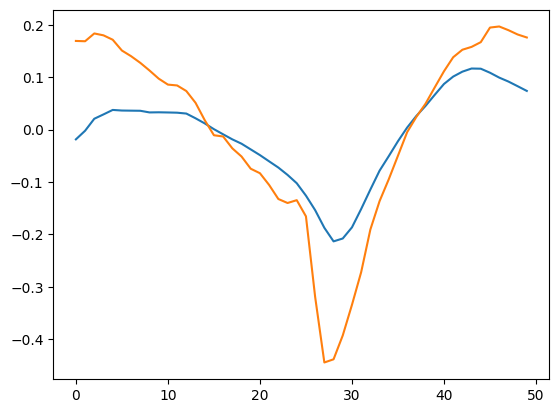

In [15]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem

path_to_add = os.path.abspath('/Users/michaelfinch/CA1_interneuron_model')

# Add the path to sys.path if it's not already there
if path_to_add not in sys.path:
    sys.path.append(path_to_add)

# Now you can proceed with your original imports
from model_class import get_animal_clean_dict_activity, fit_GLM_population, get_residual_activity_dict

filepath = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/SSTindivsomata_GLM.mat'

animal_clean_dict_activity, animal_vel_dict, animal_trials_original, animal_trials_clean, trials_to_remove_local, animal_lick_dict = get_animal_clean_dict_activity(filepath, use_final=False)

GLM_params, predicted_activity_dict = fit_GLM_population(animal_vel_dict, animal_clean_dict_activity, quintile=None, regression='ridge', alphas=None)

residual_activity_dict_SST = get_residual_activity_dict(animal_clean_dict_activity, predicted_activity_dict)


SST_list = []
SST_list_raw = []
for animal in final_activity_dict_SST:
    for cell in final_activity_dict_SST[animal]:
        SST_list.append(np.mean(final_activity_dict_SST[animal][cell], axis=1))
        SST_list_raw.append(np.mean(animal_clean_dict_activity[animal][cell], axis=1))

SST_array = np.array(SST_list)
SST_array_raw = np.array(SST_list_raw)

mean_SST_array = np.mean(SST_array, axis=0)
sem_SST_array = sem(SST_array, axis=0)

mean_SST_array_raw = np.mean(SST_array_raw, axis=0)
sem_SST_array_raw = sem(SST_array_raw, axis=0)

plt.plot(mean_SST_array)
plt.plot(mean_SST_array_raw)

0.08440753265539763
-0.09144149371001419


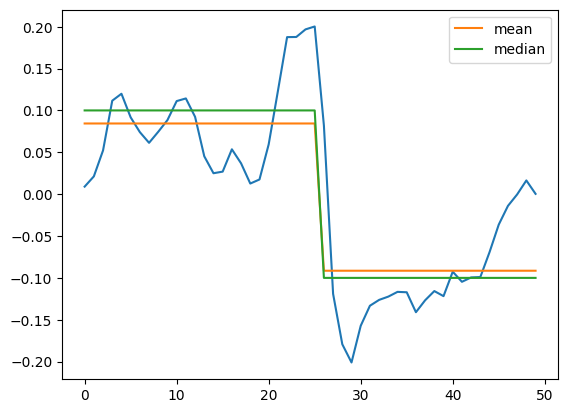

In [37]:
data_to_fit = SST_list_raw[2]

diff_data = np.abs(np.diff(data_to_fit))
change_up_loc = np.argmax(diff_data)


empty_array = np.zeros(data_to_fit.shape)
empty_array_median = np.zeros(data_to_fit.shape)

early_mean = np.mean(data_to_fit[:change_up_loc])
late_mean = np.mean(data_to_fit[change_up_loc:])

early_med = data_to_fit[:change_up_loc]
late_med = data_to_fit[change_up_loc:]

rounded_data_early = np.round(early_med, decimals=1) 
rounded_data_late = np.round(late_med, decimals=1) 
valse, countse = np.unique(rounded_data_early, return_counts=True)
valsl, countsl = np.unique(rounded_data_late, return_counts=True)
mode_valuee = valse[np.argmax(countse)]
mode_valuel = valsl[np.argmax(countsl)]

print(early_mean)
print(late_mean)

empty_array[:change_up_loc] = early_mean
empty_array[change_up_loc:] = late_mean

empty_array_median[:change_up_loc] = mode_valuee
empty_array_median[change_up_loc:] = mode_valuel

plt.plot(data_to_fit)
plt.plot(empty_array, label='mean')
plt.plot(empty_array_median, label='median')
plt.legend()
plt.show()


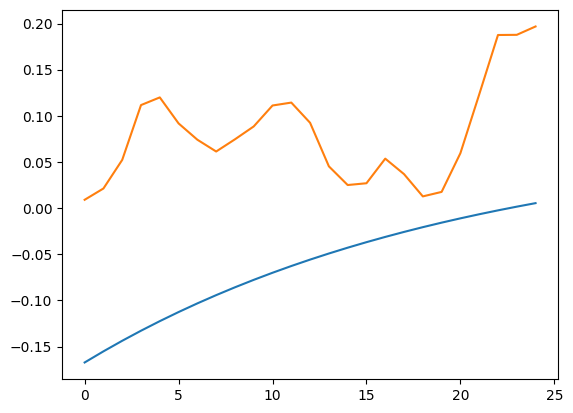

In [ ]:
# data_to_fit = (SST_list_raw[2] - np.min(SST_list_raw[2])) / (np.max(SST_list_raw[2]) - np.min(SST_list_raw[2]))

breakpoint=25

data_to_fit = SST_list_raw[2][:breakpoint]
# data_to_fit = SST_list_raw[2][breakpoint:]
# plt.plot(data_to_fit)

def exponential_curve(data_to_fit):
    breakpoint = 25
    pre = SST_list_raw[2][:breakpoint]          # length k = breakpoint
    k = len(pre)
    tau = 20.0

    b = np.mean(pre)                            # baseline
    y_edge = pre[-1]                            # value at the right edge (k-1)
    delta = y_edge - b

    x = np.arange(k, dtype=float)
    dist = (k - 1) - x                          # 0 at edge, grows as you go left

    y_fit = b + delta * np.exp(-dist / tau)

    plt.plot(pre, label="data")
    plt.plot(y_fit, label="fit")
    plt.legend()
    plt.show()


    return y_fit


y_fit = exponential_curve(data_to_fit)
plt.plot(y_fit)
plt.plot(data_to_fit)

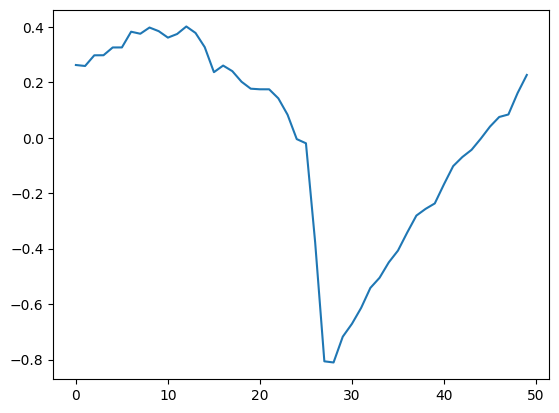

In [64]:
plt.plot(SST_list_raw[8])

{'k': 27, 'tau': 30, 'b': 0.08431793814059801, 'A': 0.03397153821841396, 'C': -0.3059703967437734, 'yhat': array([ 0.08431794,  0.08431794,  0.08431794,  0.08431794,  0.08431794,
        0.08431794,  0.08431794,  0.08431794,  0.08431794,  0.08431794,
        0.08431794,  0.08431794,  0.08431794,  0.08431794,  0.08431794,
        0.08431794,  0.08431794,  0.08431794,  0.08431794,  0.08431794,
        0.08431794,  0.08431794,  0.08431794,  0.08431794,  0.08431794,
        0.08431794,  0.08431794, -0.18768092, -0.17765002, -0.16794797,
       -0.15856399, -0.14948765, -0.14070887, -0.1322179 , -0.12400529,
       -0.11606192, -0.10837897, -0.10094789, -0.09376044, -0.08680861,
       -0.0800847 , -0.07358122, -0.06729095, -0.0612069 , -0.05532231,
       -0.04963064, -0.04412556, -0.03880096, -0.03365093, -0.02866973]), 'mse': 0.0021086743486191943}


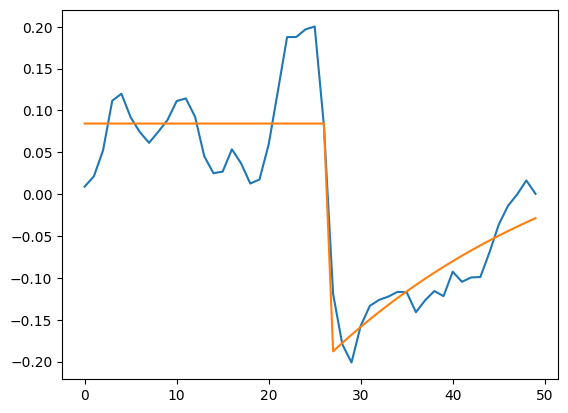

In [66]:
import numpy as np

def fit_post_step_exp(y, k, tau):
    y = np.asarray(y, float)
    n = y.size
    x = np.arange(n)

    H = (x >= k).astype(float)
    t = np.maximum(0.0, x - k)
    E = np.exp(-t / tau) * H

    # y = b*1 + A*H + C*E
    X = np.column_stack([np.ones(n), H, E])
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    yhat = X @ coef
    mse = np.mean((y - yhat)**2)
    b, A, C = coef
    return b, A, C, yhat, mse


def fit_two_regime(y):
    y = np.asarray(y, float)
    k0 = int(np.argmax(np.abs(np.diff(y))) + 1)
    k_candidates = [max(1, k0-1), k0, min(len(y)-2, k0+1)]
    taus = [2,3,4,5,6,8,10,12,15,20,30]

    best = None
    for k in k_candidates:
        for tau in taus:
            b,A,C,yhat,mse = fit_post_step_exp(y, k, tau)
            if best is None or mse < best["mse"]:
                best = dict(k=k, tau=tau, b=b, A=A, C=C, yhat=yhat, mse=mse)
    return best

best = fit_two_regime(data_to_fit)

print(best)

plt.plot(data_to_fit)
plt.plot(best['yhat'])

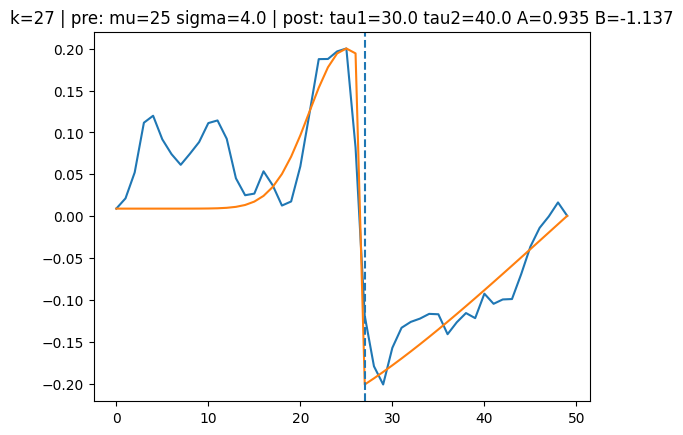

In [72]:
import numpy as np

# ---------- helpers ----------
def g_norm(t, T, tau):
    """Normalized exponential: g(0)=1, g(T)=0."""
    eT = np.exp(-T / tau)
    return (np.exp(-t / tau) - eT) / (1 - eT)

def fit_pre_gaussian_anchored(data, k, sigmas=(2,3,4,5,6,8,10,12,15)):
    """
    Pre-k kernel: b + a * exp(-(x-mu)^2/(2*sigma^2))
    with b anchored to data[0], mu anchored to argmax(data[:k]),
    and a anchored so the peak matches max(data[:k]).
    Only sigma is searched.
    """
    data = np.asarray(data, float)
    x = np.arange(len(data))
    pre = data[:k]

    b = float(data[0])                      # anchor start
    mu = int(np.argmax(pre))                # anchor peak location
    peak = float(np.max(pre))               # anchor peak value
    a = peak - b                            # anchor amplitude (can be negative too)

    best = None
    for s in sigmas:
        g = np.exp(-0.5 * ((x[:k] - mu) / float(s))**2)
        y_pre = b + a * g
        mse = float(np.mean((pre - y_pre)**2))
        if best is None or mse < best["mse"]:
            best = dict(b=b, a=a, mu=mu, sigma=float(s), y_pre=y_pre, mse=mse)
    return best

def fit_post_biexp_opposite(data, k, yk, y_end,
                            taus=(1,2,3,4,5,6,8,10,12,15,20,30,40)):
    """
    Post-k kernel: y_end + A*g(t;tau1) + B*g(t;tau2) with constraint A+B = (yk - y_end),
    and enforced opposite signs (A*B < 0).
    """
    data = np.asarray(data, float)
    n = len(data)
    x = np.arange(n)
    T = (n - 1) - k
    if T <= 0:
        raise ValueError("k too close to end")

    idx = x >= k
    t = (x[idx] - k).astype(float)
    target = data[idx]

    Delta = float(yk - y_end)
    best = None

    for tau1 in taus:
        g1 = g_norm(t, T, float(tau1))
        for tau2 in taus:
            if tau2 == tau1:
                continue
            g2 = g_norm(t, T, float(tau2))

            # y = y_end + A*g1 + (Delta - A)*g2 = y_end + Delta*g2 + A*(g1-g2)
            u = (g1 - g2)
            base = (y_end + Delta * g2)

            denom = float(np.dot(u, u))
            if denom < 1e-12:
                continue

            A = float(np.dot(u, (target - base)) / denom)
            B = float(Delta - A)

            # enforce opposite-signed components
            if A * B >= 0:
                continue

            post_fit = base + A * u
            mse = float(np.mean((target - post_fit) ** 2))

            if best is None or mse < best["mse"]:
                best = dict(
                    tau1=float(tau1), tau2=float(tau2),
                    A=A, B=B, post_fit=post_fit, mse=mse
                )
    return best

# ---------- DROP-IN: two-kernel fit (pre Gaussian + post biexp) ----------
def fit_two_kernels(data,
                    k=None,
                    pre_sigmas=(2,3,4,5,6,8,10,12,15),
                    post_taus=(1,2,3,4,5,6,8,10,12,15,20,30,40),
                    yk_mode="post5_min"):
    """
    Returns dict with y_fit (full length), k, and parameter summaries.

    Pre-k: anchored Gaussian (matches y[0], pre-peak location, and pre-peak amplitude).
    Post-k: opposite-signed biexponential anchored to yk and y_end with exact endpoint at last bin.
    """
    data = np.asarray(data, float)
    n = len(data)
    x = np.arange(n)

    # breakpoint
    if k is None:
        k = int(np.argmax(np.abs(np.diff(data))) + 1)
        k = int(np.clip(k, 1, n - 2))

    # pick yk anchor for the drop/rise (you can change this)
    if yk_mode == "pre_max":
        yk = float(np.max(data[:k]))
    elif yk_mode == "pre_min":
        yk = float(np.min(data[:k]))
    elif yk_mode == "post5_max":
        yk = float(np.max(data[k:min(n, k+5)]))
    else:  # "post5_min" default (good for a drop)
        yk = float(np.min(data[k:min(n, k+5)]))

    y_end = float(data[-1])

    # fit pre
    pre = fit_pre_gaussian_anchored(data, k, sigmas=pre_sigmas)

    # fit post
    post = fit_post_biexp_opposite(data, k, yk, y_end, taus=post_taus)
    if post is None:
        # fallback: single normalized exponential (no opposite-sign constraint)
        T = (n - 1) - k
        t = (x[x >= k] - k).astype(float)
        g = g_norm(t, T, tau=10.0)
        post_fit = y_end + (yk - y_end) * g
        post = dict(tau1=np.nan, tau2=np.nan, A=np.nan, B=np.nan, post_fit=post_fit, mse=float(np.mean((data[k:] - post_fit)**2)))

    # stitch
    y_fit = np.empty(n, float)
    y_fit[:k] = pre["y_pre"]
    y_fit[k:] = post["post_fit"]

    # optional: enforce continuity at k by shifting pre so y_fit[k-1] matches y_fit[k] (comment out if you don't want)
    # shift = y_fit[k] - y_fit[k-1]
    # y_fit[:k] += shift

    return dict(
        y_fit=y_fit,
        k=k,
        yk=yk,
        y_end=y_end,
        pre=pre,
        post=post
    )

# ---------- usage ----------
best2 = fit_two_kernels(data_to_fit, yk_mode="post5_min")
y_fit2 = best2["y_fit"]
k = best2["k"]

plt.plot(data_to_fit)
plt.plot(y_fit2)
plt.axvline(k, linestyle="--")
plt.title(
    f"k={k} | pre: mu={best2['pre']['mu']} sigma={best2['pre']['sigma']} "
    f"| post: tau1={best2['post']['tau1']} tau2={best2['post']['tau2']} "
    f"A={best2['post']['A']:.3f} B={best2['post']['B']:.3f}"
)
plt.show()


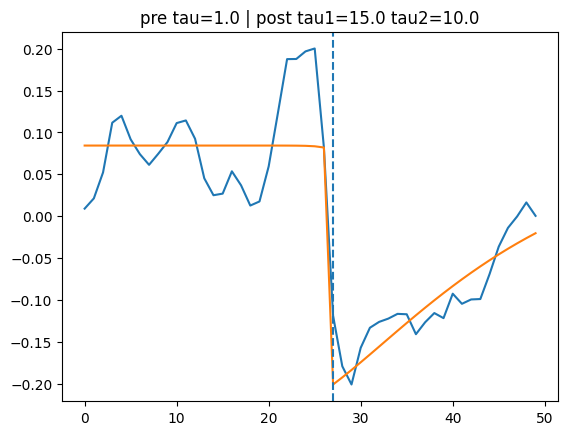

In [77]:
import numpy as np

def fit_two_exp_simple(data, breakpoint, taus=(1,2,3,4,5,6,8,10,12,15,20,30,40),
                       anchor="post5_min", enforce_opposite=True):
    data = np.asarray(data, float)
    n = len(data)
    x = np.arange(n)

    b = float(np.mean(data[:breakpoint]))  # baseline
    post = data[breakpoint:]

    # anchor value at t=0 (breakpoint)
    if anchor == "pre_max":
        y0 = float(np.max(data[:breakpoint]))
    elif anchor == "pre_min":
        y0 = float(np.min(data[:breakpoint]))
    elif anchor == "post5_max":
        y0 = float(np.max(data[breakpoint: min(n, breakpoint+5)]))
    else:  # "post5_min"
        y0 = float(np.min(data[breakpoint: min(n, breakpoint+5)]))

    delta0 = y0 - b
    t = np.arange(len(post), dtype=float)

    best = None
    for tau1 in taus:
        e1 = np.exp(-t / float(tau1))
        for tau2 in taus:
            if tau2 == tau1:
                continue
            e2 = np.exp(-t / float(tau2))

            u = (e1 - e2)
            base = b + delta0 * e2

            denom = float(np.dot(u, u))
            if denom < 1e-12:
                continue

            A = float(np.dot(u, (post - base)) / denom)
            B = float(delta0 - A)

            if enforce_opposite and (A * B >= 0):
                continue

            y_post = base + A * u
            mse = float(np.mean((post - y_post) ** 2))

            if best is None or mse < best["mse"]:
                best = dict(tau1=float(tau1), tau2=float(tau2),
                            A=A, B=B, mse=mse,
                            baseline=b, y0=y0, y_post=y_post)

    y_fit = np.full(n, b, dtype=float)
    if best is not None:
        y_fit[breakpoint:] = best["y_post"]

    return y_fit, best


def fit_pre_peak_decay(data, k, taus=(1,2,3,4,5,6,8,10,12,15,20,30,40),
                       baseline_mode="mean_pre", peak_at="argmax"):
    """
    Pre-k: decay that starts at the max (or at k-1) and decays LEFT.

    peak_at:
      - "argmax": start exactly at max(data[:k]) (best if peak earlier than k-1)
      - "k-1":    start at data[k-1] (best if event is right before breakpoint)
    """
    data = np.asarray(data, float)
    x = np.arange(len(data))
    pre = data[:k]

    baseline = float(np.mean(pre)) if baseline_mode == "mean_pre" else float(data[0])

    if peak_at == "k-1":
        peak_x = k - 1
        peak_y = float(pre[peak_x])
    else:  # "argmax"
        peak_x = int(np.argmax(pre))
        peak_y = float(np.max(pre))

    delta = peak_y - baseline

    best = None
    for tau in taus:
        y_pre = np.full(k, baseline, dtype=float)

        # only define the exponential to the LEFT of peak_x
        left = x[:k] <= peak_x
        y_pre[left] = baseline + delta * np.exp(-(peak_x - x[:k][left]) / float(tau))

        # to the right of peak, keep it flat at the peak (simple)
        right = x[:k] > peak_x
        y_pre[right] = peak_y

        mse = float(np.mean((pre - y_pre) ** 2))
        if best is None or mse < best["mse"]:
            best = dict(tau=float(tau), baseline=baseline,
                        peak_x=int(peak_x), peak_y=float(peak_y),
                        delta=float(delta), y_pre=y_pre, mse=mse)
    return best


def fit_pre_post_exp(data, k=None,
                     pre_taus=(1,2,3,4,5,6,8,10,12,15,20,30,40),
                     post_taus=(1,2,3,4,5,6,8,10,12,15,20,30,40),
                     post_anchor="post5_min",
                     pre_peak_at="k-1"):
    data = np.asarray(data, float)
    n = len(data)

    if k is None:
        k = int(np.argmax(np.abs(np.diff(data))) + 1)
        k = int(np.clip(k, 2, n-2))

    pre = fit_pre_peak_decay(data, k, taus=pre_taus, peak_at=pre_peak_at)
    y_fit_post, post = fit_two_exp_simple(data, k, taus=post_taus, anchor=post_anchor, enforce_opposite=True)

    y_fit = np.empty(n, float)
    y_fit[:k] = pre["y_pre"]
    y_fit[k:] = y_fit_post[k:]

    return y_fit, pre, post, k
import numpy as np

def fit_pre_decay_from_edge(data, k, taus=(1,2,3,4,5,6,8,10,12,15,20,30,40),
                            baseline_mode="mean_pre",
                            peak_mode="edge"):  # "edge" or "max_pre"
    """
    Pre-k: anchored exponential decay that is EXACT at the right edge.

    y_pre[x] = b + (y_peak - b) * exp(-((k-1)-x)/tau),  x in [0, k)
    So y_pre[k-1] == y_peak exactly.
    """
    data = np.asarray(data, float)
    pre = data[:k]
    x = np.arange(k, dtype=float)

    # baseline
    if baseline_mode == "data0":
        b = float(data[0])
    else:
        b = float(np.mean(pre))

    # peak anchor
    if peak_mode == "max_pre":
        y_peak = float(np.max(pre))
        peak_x = int(np.argmax(pre))
        # if max is not at the edge, you probably don't want this function
        # (use a symmetric / gaussian pre model instead)
        edge = float(peak_x)
    else:  # "edge"
        y_peak = float(pre[-1])
        edge = float(k - 1)

    delta = y_peak - b

    best = None
    for tau in taus:
        # distance from edge (k-1): at x=k-1 dist=0 => y=y_peak
        dist = (edge - x)
        y_pre = b + delta * np.exp(-dist / float(tau))

        mse = float(np.mean((pre - y_pre)**2))
        if best is None or mse < best["mse"]:
            best = dict(tau=float(tau), baseline=b, y_peak=y_peak,
                        y_pre=y_pre, mse=mse)
    return best


# k selection (same)
k = int(np.argmax(np.abs(np.diff(data_to_fit))) + 1)
k = int(np.clip(k, 2, len(data_to_fit)-2))

# PRE (fixed)
pre = fit_pre_decay_from_edge(data_to_fit, k, peak_mode="edge", baseline_mode="mean_pre")

# POST (your existing)
y_fit_post, post = fit_two_exp_simple(data_to_fit, k, anchor="post5_min", enforce_opposite=True)

# STITCH
y_fit = np.empty_like(data_to_fit, float)
y_fit[:k] = pre["y_pre"]
y_fit[k:] = y_fit_post[k:]

plt.plot(data_to_fit)
plt.plot(y_fit)
plt.axvline(k, linestyle="--")
plt.title(f"pre tau={pre['tau']} | post tau1={post['tau1']} tau2={post['tau2']}")
plt.show()


In [ ]:
from comparing_slice_TCA_methods import *

/Users/michaelfinch/CA1-interneuron-GLM/utils.py:7: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [ ]:
data_truncated_array_SST = get_truncated_to_min_data_array(residual_activity_dict_SST)


In [ ]:
data_truncated_array_EC = get_truncated_to_min_data_array(residual_activity_dict_EC)


In [ ]:

def get_r_list(fixed_activity_dict_NDNF_newest, factors_dict_NDNF_newest, data_truncated_array_SST, data_to_corr=None):

    r_list_vel = []
    vel_per_animal = []
    for animal in fixed_activity_dict_NDNF_newest:
        for cell in fixed_activity_dict_NDNF_newest[animal]:
            vel = factors_dict_NDNF_newest[animal][data_to_corr][:,:data_truncated_array_SST.shape[2]]
            vel_per_animal.append(vel)
            data = fixed_activity_dict_NDNF_newest[animal][cell][:,:data_truncated_array_SST.shape[2]]
            r, _ = pearsonr(vel.flatten(), data.flatten())
            r_list_vel.append(r)

    array_data = np.array(vel_per_animal)
    r_dict_vel = {"r_list":r_list_vel,
                  "array_data":array_data}

    return r_dict_vel


r_dict_vel = get_r_list(activity_dict_SST, factors_dict_SST, data_truncated_array_SST, data_to_corr="Velocity")
r_dict_licks = get_r_list(activity_dict_SST, factors_dict_SST, data_truncated_array_SST, data_to_corr="Licks")
            

r_dict_vel_resid = get_r_list(residual_activity_dict_SST, factors_dict_SST, data_truncated_array_SST, data_to_corr="Velocity")
r_dict_licks_resid = get_r_list(residual_activity_dict_SST, factors_dict_SST, data_truncated_array_SST, data_to_corr="Licks")

AttributeError: 'tuple' object has no attribute 'shape'

In [ ]:

def get_r_list(fixed_activity_dict_NDNF_newest, factors_dict_NDNF_newest, data_truncated_array_EC, data_to_corr=None):

    r_list_vel = []
    vel_per_animal = []
    for animal in fixed_activity_dict_NDNF_newest:
        for cell in fixed_activity_dict_NDNF_newest[animal]:
            vel = factors_dict_NDNF_newest[animal][data_to_corr][:,:data_truncated_array_EC.shape[2]]
            vel_per_animal.append(vel)
            data = fixed_activity_dict_NDNF_newest[animal][cell][:,:data_truncated_array_EC.shape[2]]
            r, _ = pearsonr(vel.flatten(), data.flatten())
            r_list_vel.append(r)

    array_data = np.array(vel_per_animal)
    r_dict_vel = {"r_list":r_list_vel,
                  "array_data":array_data}

    return r_dict_vel


r_dict_vel = get_r_list(activity_dict_EC, factors_dict_EC, data_truncated_array_EC, data_to_corr="Velocity")
r_dict_licks = get_r_list(activity_dict_EC, factors_dict_EC, data_truncated_array_EC, data_to_corr="Licks")
            

r_dict_vel_resid = get_r_list(residual_activity_dict_EC, factors_dict_EC, data_truncated_array_EC, data_to_corr="Velocity")
r_dict_licks_resid = get_r_list(residual_activity_dict_EC, factors_dict_EC, data_truncated_array_EC, data_to_corr="Licks")

In [ ]:

def get_r_list(fixed_activity_dict_NDNF_newest, factors_dict_NDNF_newest, data_truncated_array_EC, data_to_corr=None):

    r_list_vel = []
    vel_per_animal = []
    for animal in fixed_activity_dict_NDNF_newest:
        for cell in fixed_activity_dict_NDNF_newest[animal]:
            vel = factors_dict_NDNF_newest[animal][data_to_corr][:,:data_truncated_array_EC.shape[2]]
            vel_per_animal.append(vel)
            data = fixed_activity_dict_NDNF_newest[animal][cell][:,:data_truncated_array_EC.shape[2]]
            r, _ = pearsonr(vel.flatten(), data.flatten())
            r_list_vel.append(r)

    array_data = np.array(vel_per_animal)
    r_dict_vel = {"r_list":r_list_vel,
                  "array_data":array_data}

    return r_dict_vel


r_dict_vel = get_r_list(activity_dict_EC, factors_dict_EC, data_truncated_array_EC, data_to_corr="Velocity")
r_dict_licks = get_r_list(activity_dict_EC, factors_dict_EC, data_truncated_array_EC, data_to_corr="Licks")
            

r_dict_vel_resid = get_r_list(residual_activity_dict_EC, factors_dict_EC, data_truncated_array_EC, data_to_corr="Velocity")
r_dict_licks_resid = get_r_list(residual_activity_dict_EC, factors_dict_EC, data_truncated_array_EC, data_to_corr="Licks")

Loss: 0.8402883133357392 : 100%|██████████| 4000/4000 [16:55<00:00,  3.94it/s]


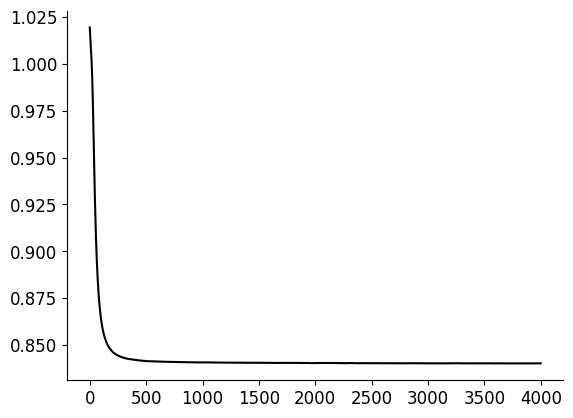

In [ ]:
model_20_EC_raw_x00 = get_the_tca_model(residual_activity_dict_EC, components=(0,20,0))
save_path = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/all_cells_truncated_EC_model.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(model_20_EC_raw_x00, f)



In [ ]:
animals_order = list(residual_activity_dict_SST.keys())
print(animals_order[:15])
for a in animals_order[:3]:
    print(a, list(residual_activity_dict_SST[a].keys())[:10])


['animal_1', 'animal_2', 'animal_3', 'animal_4', 'animal_5', 'animal_6', 'animal_7', 'animal_8', 'animal_9', 'animal_10']
animal_1 ['cell_2', 'cell_3', 'cell_4', 'cell_5', 'cell_6']
animal_2 ['cell_2', 'cell_3', 'cell_4', 'cell_5', 'cell_6', 'cell_7', 'cell_8', 'cell_9', 'cell_10', 'cell_11']
animal_3 ['cell_2', 'cell_3', 'cell_4', 'cell_5', 'cell_6', 'cell_7']


Loss: 0.3540542658425044 : 100%|██████████| 4000/4000 [01:34<00:00, 42.45it/s] 


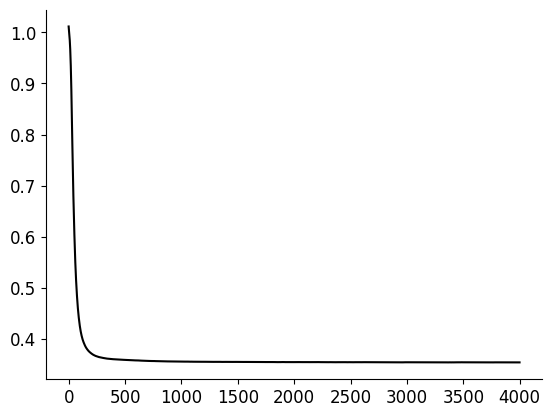

In [ ]:
model_20_SST_raw_x00 = get_the_tca_model(residual_activity_dict_SST, components=(0,20,0))
save_path = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/all_cells_truncated_SST_model.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(model_20_SST_raw_x00, f)

In [ ]:



def get_animal_clean_dict_activity(filepath, use_final=True, z_score=True):
    with h5py.File(filepath, "r") as f:
        if use_final:
            animal_group = f["animals"]
        else:
            animal_group = f["animal"]

        shiftR_refs = animal_group["ShiftR"][:]
        shiftRunning_refs = animal_group["ShiftRunning"][:]

        if use_final:
            shiftL_refs = animal_group["ShiftL"][:]
        else:
            shiftL_refs = animal_group["ShiftLrate"][:]

        animal_clean_dict_activity = {}
        animal_trials_original = []
        animal_trials_clean = []

        animal_vel_dict = {}
        animal_lick_dict = {}

        trials_to_remove_local = []  # debug tracking for count == 105
        count = 0  # global cell counter (across animals)

        for animal_idx in range(len(shiftR_refs)):
            # ΔF: (cells, trials, time)
            delta_f = np.array(f[shiftR_refs[animal_idx][0]])
            animal_trials_original.append(delta_f.shape[1])

            # velocity & lick: raw (trials, time?) → transpose: (time, trials)
            vel = np.array(f[shiftRunning_refs[animal_idx][0]]).T
            lick = np.array(f[shiftL_refs[animal_idx][0]]).T

            # --- align trial counts across df / vel / lick ---
            n_df_trials = delta_f.shape[1]
            n_vel_trials = vel.shape[1]
            n_lick_trials = lick.shape[1]

            n_trials = min(n_df_trials, n_vel_trials, n_lick_trials)

            if (n_df_trials, n_vel_trials, n_lick_trials) != (n_trials,) * 3:
                delta_f = delta_f[:, :n_trials, :]
                vel = vel[:, :n_trials]
                lick = lick[:, :n_trials]

            # preallocate clean arrays
            vel_clean = np.empty_like(vel)
            lick_clean = np.empty_like(lick)
            delta_f_clean = np.empty_like(delta_f)

            # list of trials to drop for this animal (union across cells)
            trials_to_remove_list = []

            # special case: skip cell 0 for this animal
            if animal_idx == 22:
                valid_cells = range(1, delta_f.shape[0])
            else:
                valid_cells = range(delta_f.shape[0])

            # --- clean per cell / per trial ---
            for cell in valid_cells:
                # cell_data: (time, trials)
                cell_data = delta_f[cell, :, :].T

                for trial in range(cell_data.shape[1]):
                    trial_data = cell_data[:, trial]
                    vel_data_trial = vel[:, trial]
                    lick_data_trial = lick[:, trial]

                    nan_trial = np.any(np.isnan(trial_data))
                    nan_vel = np.any(np.isnan(vel_data_trial))

                    if nan_trial or nan_vel:
                        # decide: drop or interpolate based on runs of >=5 NaNs
                        too_many_nans = (
                            has_run_of_n_nans(trial_data, n=5)
                            or has_run_of_n_nans(vel_data_trial, n=5)
                        )

                        if too_many_nans:
                            # mark for removal (for all cells later)
                            if count == 105:
                                trials_to_remove_local.append(trial)
                            if trial not in trials_to_remove_list:
                                trials_to_remove_list.append(trial)
                        else:
                            # interpolate and keep this trial
                            clean_trial = interp_nans_1d(trial_data.copy())
                            delta_f_clean[cell, trial, :] = clean_trial

                            clean_vel = interp_nans_1d(vel_data_trial.copy())
                            vel_clean[:, trial] = clean_vel

                            clean_lick = interp_nans_1d(lick_data_trial.copy())
                            lick_clean[:, trial] = clean_lick
                    else:
                        # no NaNs anywhere: just copy
                        delta_f_clean[cell, trial, :] = trial_data
                        vel_clean[:, trial] = vel_data_trial
                        lick_clean[:, trial] = lick_data_trial

                count += 1  # increment per cell

            # --- drop bad trials across all cells for this animal ---
            trials_to_remove_array = np.array(trials_to_remove_list, dtype=int)

            if trials_to_remove_array.size > 0:
                mask = np.ones(delta_f_clean.shape[1], dtype=bool)
                mask[trials_to_remove_array] = False

                delta_f_clean = delta_f_clean[:, mask, :]
                vel_clean = vel_clean[:, mask]
                lick_clean = lick_clean[:, mask]

            animal_trials_clean.append(delta_f_clean.shape[1])

            # --- build per-cell dict with z-scoring ---
            cell_dict = {}
            for cell in valid_cells:
                cell_data = delta_f_clean[cell, :, :]  # (trials, time)

                sems = sem(cell_data)
                stds = np.std(cell_data)

                if stds == 0 or not np.isfinite(stds):
                    # print(" -> zero or bad std for this cell, skipping")
                    continue

                if z_score:
                    cell_z = (cell_data - mean) / stds  # (trials, time)
                    cell_dict[f"cell_{cell+1}"] = cell_z.T  # (time, trials)
                else:
                    cell_dict[f"cell_{cell+1}"] = cell_data.T  # (time, trials)

            animal_clean_dict_activity[f"animal_{animal_idx+1}"] = cell_dict
            animal_vel_dict[f"animal_{animal_idx+1}"] = {"Velocity": vel_clean}
            animal_lick_dict[f"animal_{animal_idx+1}"] = {"Licks": lick_clean}

        return (
            animal_clean_dict_activity,
            animal_vel_dict,
            animal_trials_original,
            animal_trials_clean,
            trials_to_remove_local,
            animal_lick_dict,
        )





def get_truncated_to_min_data_array(fixed_activity_dict_NDNF_newest):
    min_val = 10000

    for animal in fixed_activity_dict_NDNF_newest:
        for cell in fixed_activity_dict_NDNF_newest[animal]:
            data = fixed_activity_dict_NDNF_newest[animal][cell]
            if data.shape[1] < min_val:
                min_val = data.shape[1]

    data_truncated_list = []
    for animal in fixed_activity_dict_NDNF_newest:
        for cell in fixed_activity_dict_NDNF_newest[animal]:
            data_truncated = fixed_activity_dict_NDNF_newest[animal][cell][:,:min_val]
            data_truncated_list.append(data_truncated)


    data_truncated_array = np.array(data_truncated_list)

    return data_truncated_array, min_val




def flatten_data(neuron_dict):
    flattened_data = {}
    for var in neuron_dict:
        flattened_data[var] = neuron_dict[var].flatten()
    return flattened_data

def fit_GLM(animal_factors_dict, neuron_activity, regression='linear', alphas=None):
    neuron_activity_flat = neuron_activity.flatten()
    flattened_data = flatten_data(animal_factors_dict)
    variable_names = [var for var in flattened_data]
    design_matrix_X = np.stack([flattened_data[var] for var in variable_names], axis=1)

    if regression == 'linear':
        model = LinearRegression()
    elif regression == 'lasso':
        model = LassoCV(alphas=alphas, cv=None) if alphas is not None else LassoCV(cv=None)
    elif regression == 'ridge':
        model = RidgeCV(alphas=alphas if alphas is not None else [0.1, 1, 10, 100, 1000, 5000], cv=None)
    elif regression == 'elastic':
        l1_ratio = [0.1, 0.3, 0.5, 0.7, 0.9, 1]
        model = ElasticNetCV(alphas=alphas if alphas is not None else [0.1, 1, 10, 100, 1000, 5000],
                             l1_ratio=l1_ratio, cv=None)

    model.fit(design_matrix_X, neuron_activity_flat)
    neuron_predicted_activity = model.predict(design_matrix_X)

    trialavg_neuron_activity = np.mean(neuron_activity, axis=1)
    trialavg_predicted_activity = np.mean(neuron_predicted_activity.reshape(neuron_activity.shape), axis=1)
    pearson_R = np.corrcoef(trialavg_predicted_activity, trialavg_neuron_activity)[0, 1]
    neuron_GLM_params = {}
    neuron_GLM_params['weights'] = {var: model.coef_[idx] for idx, var in enumerate(variable_names)}
    neuron_GLM_params['intercept'] = model.intercept_
    neuron_GLM_params['alpha'] = model.alpha_ if regression == 'ridge' else None
    neuron_GLM_params['l1_ratio'] = model.l1_ratio_ if regression == 'elastic' else None
    neuron_GLM_params['R2'] = model.score(design_matrix_X, neuron_activity_flat)
    neuron_GLM_params['pearson_R'] = pearson_R
    neuron_GLM_params['model'] = model
    return neuron_GLM_params, neuron_predicted_activity

def get_residual_activity_dict(activity_dict, predicted_activity_dict):
    residual_activity_dict = {}
    for animal in activity_dict:
        residual_activity_dict[animal] = {}
        for neuron in activity_dict[animal]:
            residual_activity_dict[animal][neuron] = activity_dict[animal][neuron] - predicted_activity_dict[animal][neuron]
    return residual_activity_dict

def fit_GLM_population(factors_dict, activity_dict, quintile=None, regression='ridge', alphas=None):
    GLM_params = {}
    predicted_activity_dict = {}

    for animal in factors_dict:
        GLM_params[animal] = {}
        predicted_activity_dict[animal] = {}
        animal_factors_dict = factors_dict[animal].copy()

        if quintile is not None:
            num_trials = animal_factors_dict['Activity'].shape[1]
            start_idx, end_idx = get_quintile_indices(num_trials, quintile)
            for var in animal_factors_dict:
                animal_factors_dict[var] = animal_factors_dict[var][:, start_idx:end_idx]

        for neuron_idx in activity_dict[animal]:
            neuron_activity = activity_dict[animal][neuron_idx]
            neuron_GLM_params, neuron_predicted_activity = fit_GLM(animal_factors_dict, neuron_activity, regression, alphas)
            GLM_params[animal][neuron_idx] = neuron_GLM_params
            predicted_activity_dict[animal][neuron_idx] = neuron_predicted_activity.reshape(activity_dict[animal][neuron_idx].shape)
                
    return GLM_params, predicted_activity_dict

def subset_variables_from_data(factors_dict, variables_to_keep=["Velocity"]):
    filtered_factors_dict = {}
    for animal in factors_dict:
        filtered_factors_dict[animal] = {}
        for variable in variables_to_keep:
            filtered_factors_dict[animal][variable] = factors_dict[animal][variable]
    return filtered_factors_dict



def has_run_of_n_nans(trial_data, n=4):
    
    nan_mask = np.isnan(trial_data)
    if not np.any(nan_mask):
        return False
    
    conv = np.convolve(nan_mask.astype(int), np.ones(n, dtype=int), mode='valid')
    return np.any(conv >= n)


def interp_nans_1d(trial_data):
    x = np.arange(trial_data.size)
    nan_mask = np.isnan(trial_data)

    if not np.any(nan_mask):
        return trial_data

    if not np.any(~nan_mask):  # all NaNs
        return trial_data

    trial_data[nan_mask] = np.interp(x[nan_mask], x[~nan_mask], trial_data[~nan_mask])
    return trial_data



In [ ]:
filepath = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/SSTindivsomata_GLM.mat'

animal_clean_dict_activity, animal_vel_dict, animal_trials_original, animal_trials_clean, trials_to_remove_local, animal_lick_dict = get_animal_clean_dict_activity(filepath, use_final=False, z_score=True)

GLM_params, predicted_activity_dict = fit_GLM_population(animal_vel_dict, animal_clean_dict_activity, quintile=None, regression='ridge', alphas=None)

residual_activity_dict_SST = get_residual_activity_dict(animal_clean_dict_activity, predicted_activity_dict)


In [ ]:

filepath = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/NDNF_E0A1B1_251107.mat'

animal_clean_dict_activity_NDNF, animal_vel_dict, animal_trials_original, animal_trials_clean, trials_to_remove_local, animal_lick_dict = get_animal_clean_dict_activity(filepath)

GLM_params, predicted_activity_dict = fit_GLM_population(animal_vel_dict, animal_clean_dict_activity_NDNF, quintile=None, regression='ridge', alphas=None)

residual_activity_dict_NDNF_new = get_residual_activity_dict(animal_clean_dict_activity_NDNF, predicted_activity_dict)

clean_resid_activity_dict_NDNF_newest = {}

clean_raw_activity_dict_NDNF_newest = {}


cell_list_raw = []
cell_list_resid = []

NDNF_model_dict_clean = {}

with open('/Users/michaelfinch/CA1-interneuron-GLM/datasets/better_NDNF_fixed_model_dict_clean.pkl', 'rb') as f:
    NDNF_model_dict = pickle.load(f)


for idx, animal in enumerate(residual_activity_dict_NDNF_new):
    if 14 < idx < 29:
        for cell in residual_activity_dict_NDNF_new[animal]:
            clean_resid_activity_dict_NDNF_newest[f"animal_{idx+1}"] = residual_activity_dict_NDNF_new[animal]
            clean_raw_activity_dict_NDNF_newest[f"animal_{idx+1}"] = animal_clean_dict_activity_NDNF[animal]

            cell_list_raw.append(np.mean(animal_clean_dict_activity_NDNF[animal][cell], axis=1))
            cell_list_resid.append(np.mean(residual_activity_dict_NDNF_new[animal][cell], axis=1))

            NDNF_model_dict_clean[animal] = NDNF_model_dict[animal] #[idx_for_model_clean]


       




In [ ]:
len(clean_resid_activity_dict_NDNF_newest)

14

Text(0.5, 0, 'Position Bins')

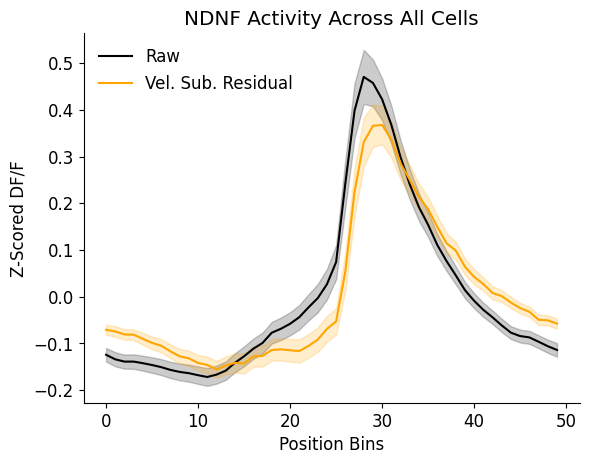

In [ ]:
cell_list_raw_array = np.array(cell_list_raw)
cell_list_resid_array = np.array(cell_list_resid)

mean_cell_list_raw_array = np.mean(cell_list_raw_array, axis=0)
mean_cell_list_resid_array = np.mean(cell_list_resid_array, axis=0)

sem_cell_list_raw_array = sem(cell_list_raw_array, axis=0)
sem_cell_list_resid_array = sem(cell_list_resid_array, axis=0)


plt.plot(mean_cell_list_raw_array, color='k', label="Raw")
plt.fill_between(range(len(mean_cell_list_raw_array)), mean_cell_list_raw_array-sem_cell_list_raw_array, mean_cell_list_raw_array+sem_cell_list_raw_array, alpha=0.2, color='k')

plt.plot(mean_cell_list_resid_array, color='orange', label="Vel. Sub. Residual")
plt.fill_between(range(len(mean_cell_list_resid_array)), mean_cell_list_resid_array-sem_cell_list_resid_array, mean_cell_list_resid_array+sem_cell_list_resid_array, alpha=0.2, color='orange')

plt.legend()
plt.title("NDNF Activity Across All Cells")
plt.ylabel("Z-Scored DF/F")
plt.xlabel("Position Bins")

In [ ]:
    
# NDNF_model_dict_clean = {}

# with open('/Users/michaelfinch/CA1-interneuron-GLM/datasets/better_NDNF_cued_model_dict_clean.pkl', 'rb') as f:
#     NDNF_model_dict = pickle.load(f)

# save_path = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/all_cells_truncated_cued_model.pkl'
# with open(save_path, 'rb') as f:
#     sliceTCA_model = pickle.load(f)

# clean_resid_activity_dict_NDNF_newest = {}

# clean_velocity_dict_NDNF_newest = {}

# clean_lick_dict_NDNF_newest = {}


# cell_count = 0
# for idx, animal in enumerate(residual_activity_dict_NDNF_new):
#     if idx > 28:
#         idx_for_model_clean = idx-29
#         animal_key = f"animal_{idx+1}"
#         for cell in residual_activity_dict_NDNF_new[animal]:
#             cell_count+=1

#         if use_all:
#             if idx in gospel_labels_dict["B1_first_or_only"] or idx in gospel_labels_dict['B1_after_A1']:
#                 print(f"session idx {idx} in gospel_labels_dict[B1_first_or_only] {gospel_labels_dict['B1_first_or_only']}")
#                 clean_resid_activity_dict_NDNF_newest[f"animal_{idx+1}"] = residual_activity_dict_NDNF_new[animal]
#                 clean_velocity_dict_NDNF_newest[f"animal_{idx+1}"] = animal_vel_dict[animal]
#                 clean_lick_dict_NDNF_newest [f"animal_{idx+1}"] = animal_lick_dict[animal]
#                 animal_ids_for_condition_list.append(animal_id_per_session_list[idx])

#                 idx_array_one = np.array(gospel_labels_dict["B1_first_or_only"])
#                 idx_array_two = np.array(gospel_labels_dict["B1_after_A1"])

#                 all_idx = np.concatenate([idx_array_one, idx_array_two])

#                 animal_included_list = np.array(animal_id_per_session_list)[all_idx]

#                 fig.suptitle(f"All Cued Sessions: {animal_included_list}")

#                 NDNF_model_dict_clean[animal_key] = NDNF_model_dict[animal] #[idx_for_model_clean]


def reshape_contig_dict(cued_contig_dict, NDNF_cued_model_dict_clean):
    # Match the old structure: outer key is rank (20)
    cued_contig_final = {20: {}}

    for idx, animal in enumerate(NDNF_cued_model_dict_clean):
    # for animal in cued_contig_dict:  # animal index: 0,1,2,...
        cued_contig_final[20][animal] = {}

        print(f"animal {animal} NDNF_cued_model_dict_clean.keys() {NDNF_cued_model_dict_clean.keys()}")

        for cell in cued_contig_dict[animal]:  # cell index: 0,1,2,...
            # 1) SliceTCA model object
            model_obj = NDNF_cued_model_dict_clean[animal][cell]

            # 2) Internals for this cell – currently under "cell_0"
            internals_cell0 = cued_contig_dict[animal][cell]["cell_0"]

            # 3) Rename "cell_0" → f"cell_{cell}" to match old API
            per_cell_internals = {f"cell_{cell}": internals_cell0}

            # 4) Store as [model_obj, per_cell_internals]
            cued_contig_final[20][animal][cell] = [model_obj, per_cell_internals]

    return cued_contig_final



def preprocess_animal(NDNF_fixed_model_dict, residual_activity_dict, num_clusters=8, reassign_clusters=False, x00=True, umap=True, contiguous=True, ranks=20):
    # tensor_list_by_animal_all_SST = []
    # for animal in residual_activity_dict:
    #     neural_data = ut.get_animal_neural_tensor(residual_activity_dict, animal=animal)
    #     neural_data_tensor = torch.tensor(neural_data)
    #     # Normalize per cell
    #     for i in range(neural_data_tensor.shape[1]):
    #         cell = neural_data_tensor[:, i, :]
    #         min_val = cell.min()
    #         max_val = cell.max()
    #         neural_data_tensor[:, i, :] = (cell - min_val) / (max_val - min_val + 1e-8)
    #     tensor_list_by_animal_all_SST.append(neural_data_tensor)


    internals_per_animal_dict_EC_animal_x00_regkmean = {}
    
    for idx, animal in enumerate(residual_activity_dict):
        internals_per_animal_dict_EC_animal_x00_regkmean_cell = {}
        for idt, cell in enumerate(residual_activity_dict[animal]):

            cell_data = residual_activity_dict[animal][cell].T
            cell_data = ((cell_data-np.min(cell_data)) / np.max(cell_data) - np.min(cell_data))
            cell_data_3d = np.expand_dims(cell_data, axis=1)
            cell_data_3d = torch.from_numpy(cell_data_3d)
            cell_model = NDNF_fixed_model_dict[animal][cell]


    # internals_per_animal_dict_EC_animal_x00_regkmean = {}
    # for animal in animal_EC_model_ranks20_contig_x00[ranks]:
    #     animal_model = animal_EC_model_ranks20_contig_x00[ranks][animal][0]
        # tensor_for_animal = tensor_list_by_animal_all_SST[animal]
            internals_dict = get_animal_model_reconstruction_dict_mod(cell_model, cell_data_3d, max_clusters=num_clusters, display=False, reassign_small_clusters=reassign_clusters, x00=x00, use_umap=umap, use_breakpoints=contiguous)

            internals_per_animal_dict_EC_animal_x00_regkmean_cell[cell] = internals_dict
        
        internals_per_animal_dict_EC_animal_x00_regkmean[animal] = internals_per_animal_dict_EC_animal_x00_regkmean_cell

    return internals_per_animal_dict_EC_animal_x00_regkmean


reassigned_dict_cell_tca = preprocess_animal(NDNF_model_dict_clean, clean_resid_activity_dict_NDNF_newest, num_clusters=8, reassign_clusters=True, x00=True, umap=False, contiguous=False, ranks=20)

contig_dict_all_cell_tca = preprocess_animal(NDNF_model_dict_clean, clean_resid_activity_dict_NDNF_newest, num_clusters=5, reassign_clusters=False, x00=True, umap=False, contiguous=True, ranks=20)


print(f"contig_dict_all_cell_tca.keys() {contig_dict_all_cell_tca.keys()}")


contig_dict = reshape_contig_dict(contig_dict_all_cell_tca, NDNF_model_dict_clean)

reassigned_dict = reshape_contig_dict(reassigned_dict_cell_tca, NDNF_model_dict_clean)

cp_dict_NDNF = get_cp_dict(contig_dict)

Processing cell 0...

clusters_chosen = 1
Before reassignment:
  Cluster 0: 223 trials
After reassignment:
  Cluster 0: 223 trials

clusters_chosen = 2
Before reassignment:
  Cluster 0: 183 trials
  Cluster 1: 40 trials
After reassignment:
  Cluster 0: 183 trials
  Cluster 1: 40 trials

clusters_chosen = 3
Before reassignment:
  Cluster 0: 71 trials
  Cluster 1: 22 trials
  Cluster 2: 130 trials
After reassignment:
  Cluster 0: 71 trials
  Cluster 1: 22 trials
  Cluster 2: 130 trials

clusters_chosen = 4
Before reassignment:
  Cluster 0: 79 trials
  Cluster 1: 7 trials
  Cluster 2: 117 trials
  Cluster 3: 20 trials
After reassignment:
  Cluster 0: 79 trials
  Cluster 1: 7 trials
  Cluster 2: 117 trials
  Cluster 3: 20 trials

clusters_chosen = 5
Before reassignment:
  Cluster 0: 77 trials
  Cluster 1: 6 trials
  Cluster 2: 119 trials
  Cluster 3: 20 trials
  Cluster 4: 1 trials
  Reassigning cluster 4 (size=1)...
After reassignment:
  Cluster 0: 77 trials
  Cluster 1: 7 trials
  Cluste

Text(0.5, 0, 'Position Bins')

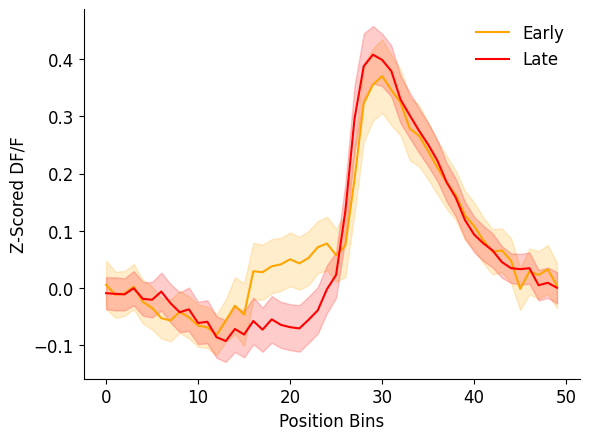

In [ ]:
early_list = []
late_list = []

for animal in clean_resid_activity_dict_NDNF_newest:
    for cell in clean_resid_activity_dict_NDNF_newest[animal]:
        early_cp = cp_dict_NDNF[animal][cell][0]
        late_cp = cp_dict_NDNF[animal][cell][1]
        early_data = clean_resid_activity_dict_NDNF_newest[animal][cell][:,:early_cp]
        late_data = clean_resid_activity_dict_NDNF_newest[animal][cell][:,late_cp:]
        early_list.append(np.mean(early_data, axis=1))
        late_list.append(np.mean(late_data, axis=1))
                         
early_array = np.array(early_list)
late_array = np.array(late_list)

mean_early_array = np.mean(early_array, axis=0)
mean_late_array = np.mean(late_array, axis=0)

sem_early_array = sem(early_array, axis=0)
sem_late_array = sem(late_array, axis=0)

plt.plot(mean_early_array, label="Early", color='orange')
plt.fill_between(range(len(mean_early_array)), mean_early_array+sem_early_array, mean_early_array-sem_early_array, alpha=0.2, color='orange')

plt.plot(mean_late_array, label="Late", color='r')
plt.fill_between(range(len(mean_late_array)), mean_late_array+sem_late_array, mean_late_array-sem_late_array, alpha=0.2, color='r')
plt.legend()
plt.ylabel("Z-Scored DF/F")
plt.xlabel("Position Bins")

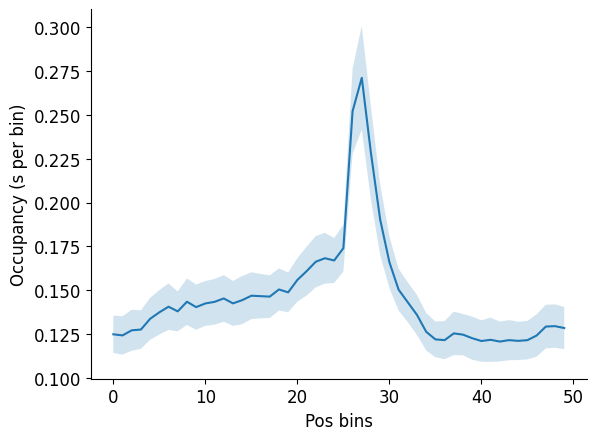

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem

track_length_cm = 180  
n_bins = 50             
dx_m = (track_length_cm / 100) / n_bins   

animal_occ_list = []

for animal in animal_vel_dict:
    V = animal_vel_dict[animal]["Velocity"]      # shape: (bins, trials)

    V_clip = np.clip(V, 1e-3, None)              
    dt = dx_m / V_clip                           

    mean_dt = np.mean(dt, axis=1)
    animal_occ_list.append(mean_dt)

animal_occ_array = np.array(animal_occ_list)     # (n_animals, bins)

mean_occ = np.mean(animal_occ_array, axis=0)
sem_occ  = sem(animal_occ_array, axis=0)

plt.plot(mean_occ)
plt.fill_between(np.arange(len(mean_occ)), mean_occ - sem_occ, mean_occ + sem_occ, alpha=0.2)
plt.ylabel("Occupancy (s per bin)")
plt.xlabel("Pos bins")
plt.show()


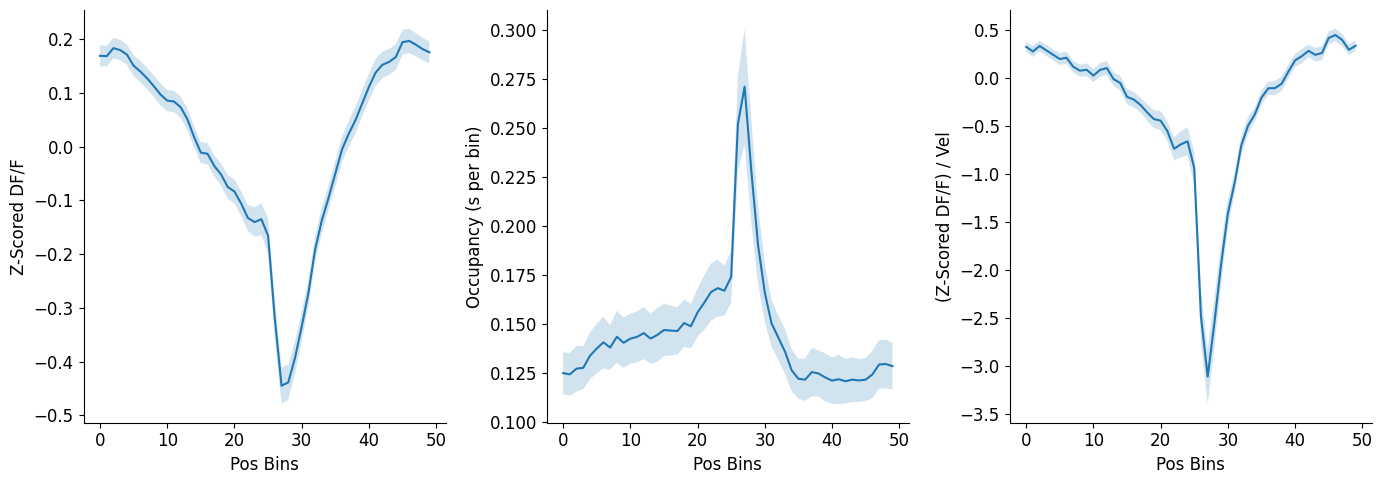

TypeError: Invalid shape () for image data

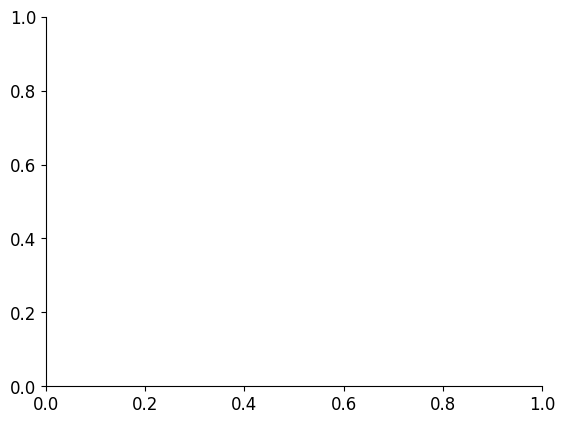

In [ ]:
raw_dff_list = []
div_data_list = []
div_data_list_full = []
for animal in animal_clean_dict_activity:
    for cell in animal_clean_dict_activity[animal]:
        raw_dff_list.append(np.mean(animal_clean_dict_activity[animal][cell], axis=1))
        
        V = animal_vel_dict[animal]["Velocity"]

        V_clip = np.clip(V, 1e-3, None)              
        dt = dx_m / V_clip                           

        div_data = animal_clean_dict_activity[animal][cell] / animal_vel_dict[animal]["Velocity"] # * dt 
        # div_data_z = (div_data - np.mean(div_data)) / np.std(div_data)
        # div_data_list.append(np.mean(div_data_z, axis=1))
        div_data_list.append(np.mean(div_data, axis=1))
        # div_data_list_full.append(div_data_z[:,:63])
        
raw_dff_array = np.array(raw_dff_list)

mean_raw_dff_array = np.mean(raw_dff_array, axis=0)
sem_raw_dff_array = sem(raw_dff_array, axis=0)

fig, axs = plt.subplots(1,3, figsize=(14,5))

axs[0].plot(mean_raw_dff_array), 
axs[0].fill_between(range(len(mean_raw_dff_array)), mean_raw_dff_array+sem_raw_dff_array, mean_raw_dff_array-sem_raw_dff_array, alpha=0.2)

axs[0].set_ylabel("Z-Scored DF/F")
axs[0].set_xlabel("Pos Bins")



track_length_cm = 180  
n_bins = 50             
dx_m = (track_length_cm / 100) / n_bins   

animal_occ_list = []

for animal in animal_vel_dict:
    V = animal_vel_dict[animal]["Velocity"]      # shape: (bins, trials)

    V_clip = np.clip(V, 1e-3, None)              
    dt = dx_m / V_clip                           

    mean_dt = np.mean(dt, axis=1)
    animal_occ_list.append(mean_dt)

animal_occ_array = np.array(animal_occ_list)     # (n_animals, bins)

mean_occ = np.mean(animal_occ_array, axis=0)
sem_occ  = sem(animal_occ_array, axis=0)

axs[1].plot(mean_occ)
axs[1].fill_between(np.arange(len(mean_occ)), mean_occ - sem_occ, mean_occ + sem_occ, alpha=0.2)
axs[1].set_ylabel("Occupancy (s per bin)")
axs[1].set_xlabel("Pos Bins")


div_data_array = np.array(div_data_list)
mean_div_data_array = np.mean(div_data_array, axis=0)
sem_div_data_array = sem(div_data_array, axis=0)

axs[2].plot(mean_div_data_array)
axs[2].fill_between(np.arange(len(mean_div_data_array)), mean_div_data_array - sem_div_data_array, mean_div_data_array + sem_div_data_array, alpha=0.2)
axs[2].set_ylabel("(Z-Scored DF/F) / Vel")
axs[2].set_xlabel("Pos Bins")

plt.tight_layout()
plt.show()

div_data_array_full = np.array(div_data_list_full)
mean_cells = np.mean(div_data_array_full, axis=0)
plt.imshow(mean_cells.T, aspect='auto')


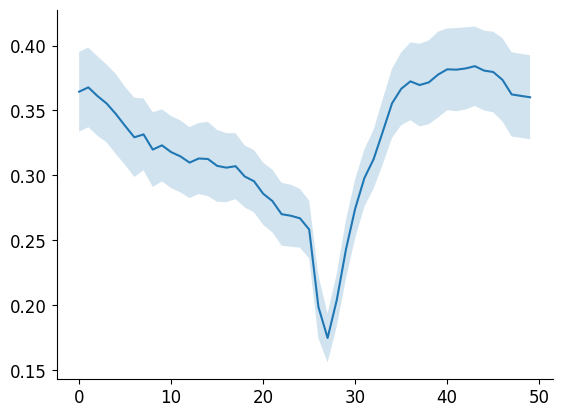

In [ ]:
animal_velocity_list = []
for animal in animal_vel_dict:
    mean_vel = np.mean(animal_vel_dict[animal]["Velocity"], axis=1)
    animal_velocity_list.append(mean_vel)

animal_velocity_array = np.array(animal_velocity_list)

mean_animal_velocity_array = np.mean(animal_velocity_array, axis=0)
sem_animal_velocity_array = sem(animal_velocity_array, axis=0)

plt.plot(mean_animal_velocity_array), 
plt.fill_between(range(len(mean_animal_velocity_array)), mean_animal_velocity_array+sem_animal_velocity_array, mean_animal_velocity_array-sem_animal_velocity_array, alpha=0.2)
plt.ylabel("Velocity m/s")
plt.xlabel("Pos Bins")

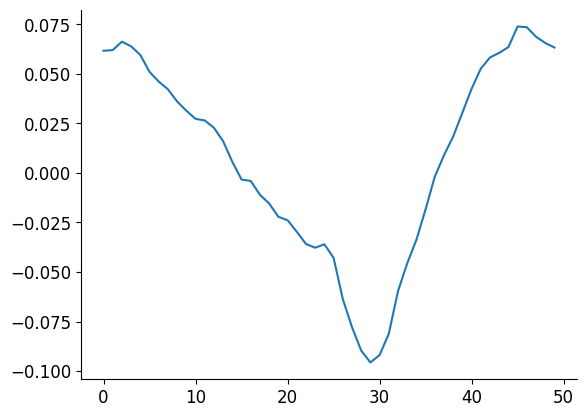

In [ ]:
div_data = mean_raw_dff_array * mean_animal_velocity_array
plt.plot(div_data)

Text(0.5, 0, 'Pos bins')

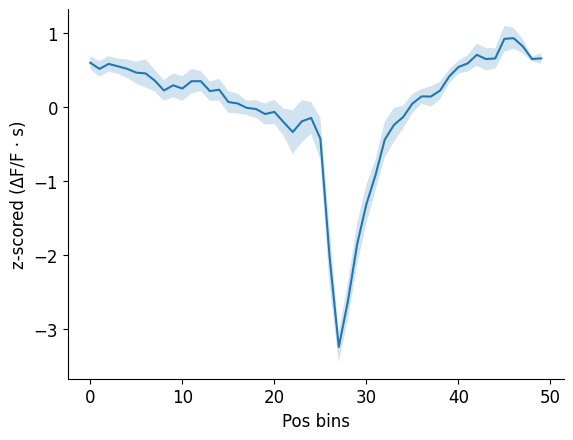

In [ ]:
import numpy as np
from scipy.stats import zscore

dx_m = 0.036  # <-- set this correctly (meters per spatial bin)

Fs_by_animal = []
for animal in animal_clean_dict_activity:
    # stack cells: (n_cells, bins, trials)
    cells = []
    for cell in animal_clean_dict_activity[animal]:
        cells.append(animal_clean_dict_activity[animal][cell])  # (bins, trials), already z-scored DF/F
    cells = np.stack(cells, axis=0)

    # mean across cells -> (bins, trials)
    F = cells.mean(axis=0)

    # velocity -> (bins, trials)
    V = animal_vel_dict[animal]["Velocity"]

    # dwell time per bin per trial
    V_clip = np.clip(V, 1e-3, None)
    dt = dx_m / V_clip  # seconds in bin

    # DF/F·s
    Fs = F * dt  # (bins, trials)

    # trial-average spatial profile
    Fs_mean = Fs.mean(axis=1)  # (bins,)

    # z-score across space (this is usually what makes "peak vs dip" pop)
    Fs_z = zscore(Fs_mean, nan_policy='omit')

    Fs_by_animal.append(Fs_z)

Fs_by_animal = np.vstack(Fs_by_animal)  # (n_animals, bins)
mean_Fs = Fs_by_animal.mean(axis=0)
sem_Fs  = Fs_by_animal.std(axis=0, ddof=1) / np.sqrt(Fs_by_animal.shape[0])

plt.plot(mean_Fs)
plt.fill_between(np.arange(len(mean_Fs)), mean_Fs-sem_Fs, mean_Fs+sem_Fs, alpha=0.2)
plt.ylabel("z-scored (ΔF/F · s)")
plt.xlabel("Pos bins")


In [40]:

save_path = "/Users/michaelfinch/CA1_interneuron_model/misc/sst_kurt_param_pool.pkl"
with open(save_path, 'rb') as f:
    param_pool_ndnf = pickle.load(f)


param_pool_ndnf.keys()

dict_keys(['max_loc_overall', 'min_loc_overall', 'max_amp_overall', 'min_amp_overall', 'final_sigma_max_array', 'final_sigma_min_array', 'final_kurtosis_max_array', 'final_kurtosis_min_array', 'final_slope_array', 'max_loc_early', 'min_loc_early', 'max_amp_early', 'min_amp_early', 'max_loc_middle', 'min_loc_middle', 'max_amp_middle', 'min_amp_middle', 'max_loc_late', 'min_loc_late', 'max_amp_late', 'min_amp_late', 'baseline_array', 'baseline_early_array', 'baseline_middle_array', 'baseline_late_array', 'early_expression_array', 'middle_expression_array', 'late_expression_array'])

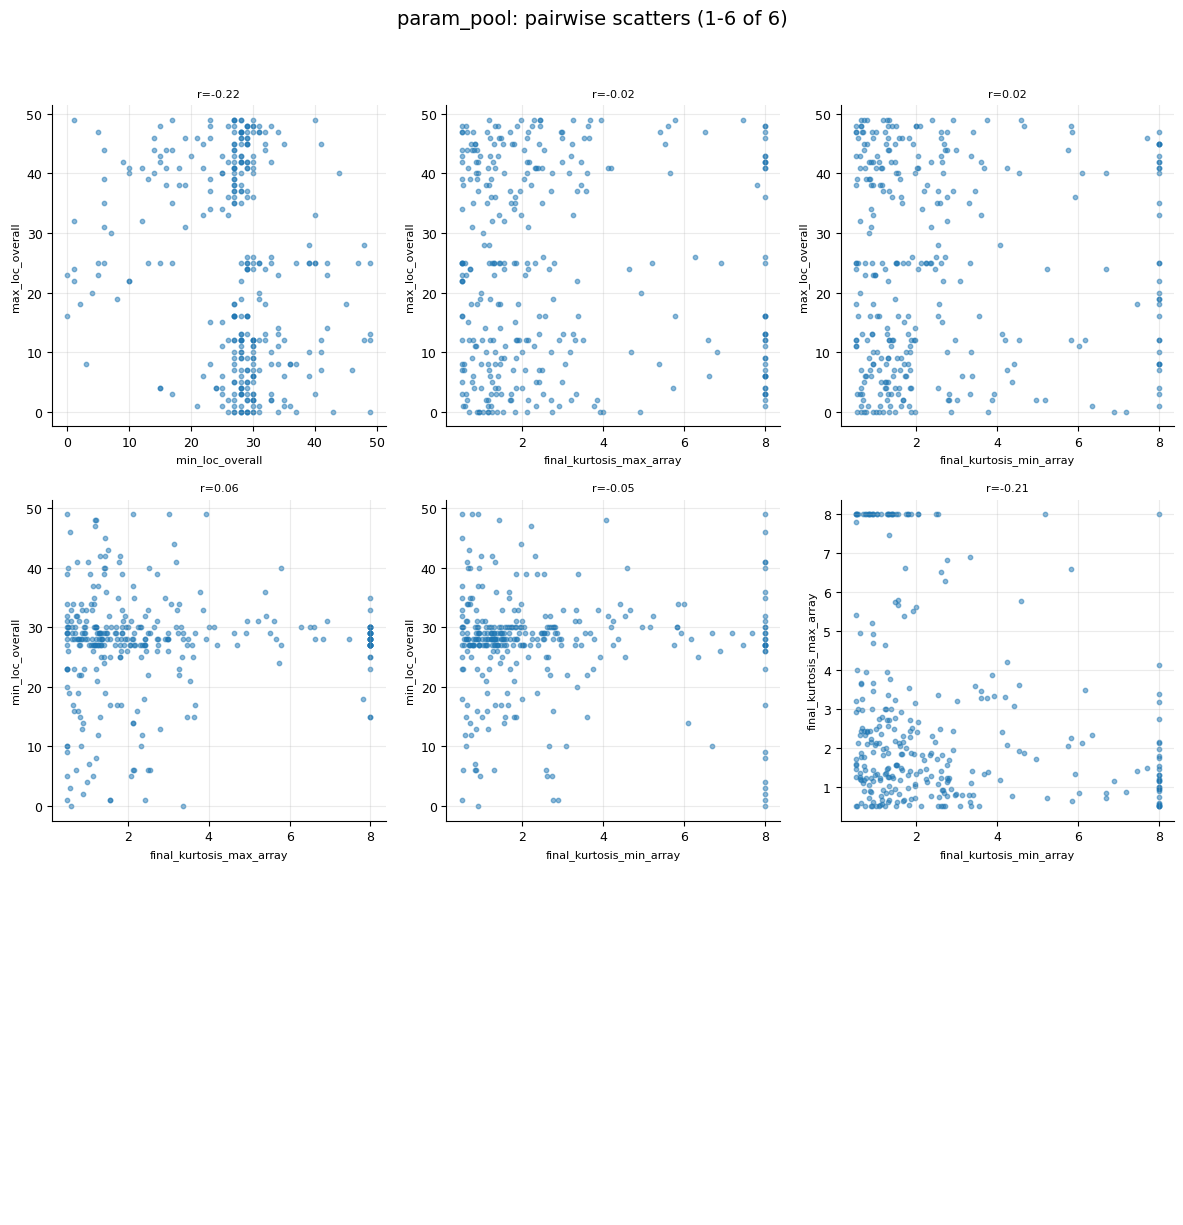

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

def plot_param_pool_pairwise_pages(param_pool, vars_keep=None, nrows=3, ncols=3,
                                  s=10, alpha=0.5, marker='o',
                                  add_corr=True, suptitle_prefix="param_pool"):
    """
    Plots all unique pairwise scatterplots among vars_keep, paginated into nrows x ncols figures.
    Ignores NaN/inf pairwise. Optionally annotates Pearson r in each panel.
    """
    if vars_keep is None:
        # default: keep only the "overall" + non-phase arrays you listed
        vars_keep = [
            "max_loc_overall", "min_loc_overall",
            # "max_amp_overall", "min_amp_overall",
            # "final_sigma_max_array", "final_sigma_min_array",
            "final_kurtosis_max_array", "final_kurtosis_min_array",
            # "final_slope_array",
            # "baseline_array",
        ]

    # pull arrays + force float
    X = {}
    for k in vars_keep:
        if k not in param_pool:
            print(f"⚠️ missing key: {k} (skipping)")
            continue
        X[k] = np.asarray(param_pool[k], dtype=float)

    keys = list(X.keys())
    if len(keys) < 2:
        raise ValueError("Need at least 2 variables to plot.")

    pairs = list(combinations(keys, 2))  # unique pairs
    per_fig = nrows * ncols

    for page_start in range(0, len(pairs), per_fig):
        chunk = pairs[page_start:page_start + per_fig]

        fig, axs = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))
        axs = np.array(axs).ravel()

        for ax_i, (y_name, x_name) in enumerate(chunk):
            ax = axs[ax_i]

            x = X[x_name]
            y = X[y_name]

            # pairwise finite mask (in case lengths differ or NaNs)
            n = min(len(x), len(y))
            x = x[:n]; y = y[:n]
            m = np.isfinite(x) & np.isfinite(y)
            x = x[m]; y = y[m]

            ax.scatter(x, y, s=s, alpha=alpha, marker=marker)
            ax.set_xlabel(x_name)
            ax.set_ylabel(y_name)
            ax.grid(alpha=0.25)

            if add_corr and x.size >= 3:
                r = np.corrcoef(x, y)[0, 1]
                ax.set_title(f"r={r:.2f}")
            else:
                ax.set_title("")

        # turn off unused axes on last page
        for j in range(len(chunk), per_fig):
            axs[j].axis("off")

        fig.suptitle(f"{suptitle_prefix}: pairwise scatters ({page_start+1}-{page_start+len(chunk)} of {len(pairs)})",
                     y=1.02, fontsize=14)
        plt.tight_layout()
        plt.show()


# ---- usage ----
plot_param_pool_pairwise_pages(param_pool_ndnf)


In [ ]:
save_path = f"/Users/michaelfinch/CA1_interneuron_model/misc/reconstructed_data_.pkl"
with open(save_path, 'wb') as f:
    pickle.dump(final_activity_dict, f)

In [ ]:
residual_data_all = []
for animal in residual_activity_dict_SST:
    for cell in residual_activity_dict_SST[animal]:
        residual_activity_dict_SST[animal]

residual_data_all_array = np.array(residual_data_all)

dict_keys(['animal_1', 'animal_2', 'animal_3', 'animal_4', 'animal_5', 'animal_6', 'animal_7', 'animal_8', 'animal_9', 'animal_10'])

In [ ]:
min_val = 1000000

for animal in residual_activity_dict_SST:
    for cell in residual_activity_dict_SST[animal]:
        cell_size = residual_activity_dict_SST[animal][cell].shape[1]
        if cell_size < min_val:
            min_val = cell_size


print(min_val)


63


In [ ]:
for animal in residual_activity_dict_SST:
    # grab any one cell
    any_cell = next(iter(residual_activity_dict_SST[animal].values()))
    n_act = any_cell.shape[1]  # (time, trials)

    n_vel = animal_vel_dict[animal]["Velocity"].shape[1]
    n_lick = animal_lick_dict[animal]["Licks"].shape[1]

    if (n_act != n_vel) or (n_act != n_lick):
        print(animal, "activity trials:", n_act, "vel trials:", n_vel, "lick trials:", n_lick)


vel.flatten() (3150,), data.flatten() (3150,)
vel.flatten() (3150,), data.flatten() (3150,)
vel.flatten() (3150,), data.flatten() (3150,)
vel.flatten() (3150,), data.flatten() (3150,)
vel.flatten() (3150,), data.flatten() (3150,)
vel.flatten() (3150,), data.flatten() (3150,)
vel.flatten() (3150,), data.flatten() (3150,)
vel.flatten() (3150,), data.flatten() (3150,)
vel.flatten() (3150,), data.flatten() (3150,)
vel.flatten() (3150,), data.flatten() (3150,)
vel.flatten() (3150,), data.flatten() (3150,)
vel.flatten() (3150,), data.flatten() (3150,)
vel.flatten() (3150,), data.flatten() (3150,)
vel.flatten() (3150,), data.flatten() (3150,)
vel.flatten() (3150,), data.flatten() (3150,)
vel.flatten() (3150,), data.flatten() (3150,)
vel.flatten() (3150,), data.flatten() (3150,)
vel.flatten() (3150,), data.flatten() (3150,)
vel.flatten() (3150,), data.flatten() (3150,)
vel.flatten() (3150,), data.flatten() (3150,)
vel.flatten() (3150,), data.flatten() (3150,)
vel.flatten() (3150,), data.flatte

ValueError: bottom cannot be >= top

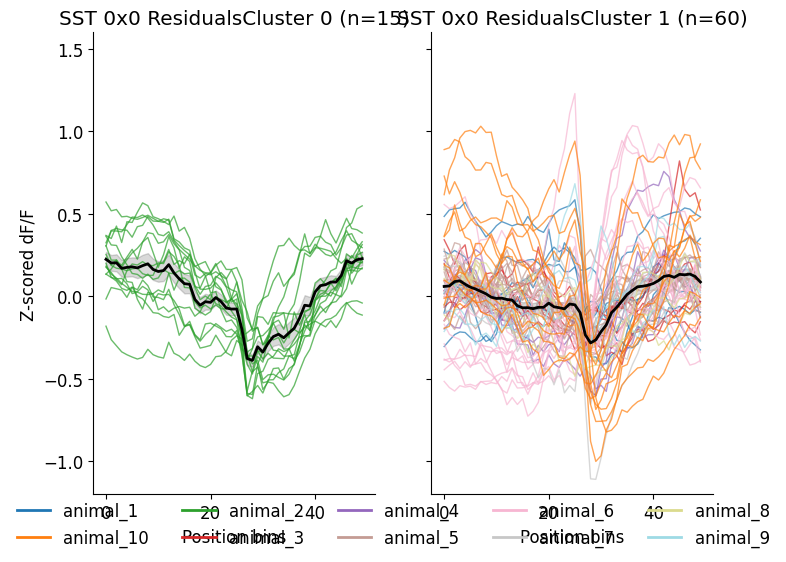

In [ ]:
# model_20_SST_raw_x00 = get_the_tca_model(residual_activity_dict_SST, components=(0,20,0))

def get_truncated_to_min_data_array(activity_dict):
    # deterministic ordering
    animals = sorted(activity_dict.keys(), key=lambda a: int(a.split("_")[1]))

    # find global min trials
    min_val = min(
        activity_dict[a][c].shape[1]
        for a in animals
        for c in sorted(activity_dict[a].keys(), key=lambda s: int(s.split("_")[1]))
    )

    data_list = []
    idx_to_key = []  # <-- the important part

    for a in animals:
        cell_keys = sorted(activity_dict[a].keys(), key=lambda s: int(s.split("_")[1]))
        for c in cell_keys:
            data_list.append(activity_dict[a][c][:, :min_val])
            idx_to_key.append((a, c))

    return np.array(data_list), min_val, idx_to_key

def plot_cluster_traces_by_animal(
    means_dict_cluster,
    fixed_activity_dict,
    K,
    ylim=(-1.1, 2.6),
    title_prefix="",
    ncol=5,
    spacing=0.2,
):
    # --- TA array + the ordering map used to build it ---
    data, min_val, idx_to_key = get_truncated_to_min_data_array(fixed_activity_dict)
    ta = data.mean(axis=2)  # (n_cells, n_pos)
    n_cells, n_pos = ta.shape

    # array-index -> animal mapping (always valid)
    idx_to_animal = {i: animal for i, (animal, cell_key) in enumerate(idx_to_key)}

    # --- cluster indices ---
    clust_idx_dict = means_dict_cluster[K]["cell_ids_per_cluster_dict"]
    uniq = sorted(clust_idx_dict.keys())

    # sanity: are these array indices?
    all_ids = np.concatenate([np.asarray(clust_idx_dict[k]).ravel() for k in uniq])
    ids_are_array_idx = (all_ids.min() >= 0) and (all_ids.max() < n_cells)

    if not ids_are_array_idx:
        raise ValueError(
            "Your cluster 'cell_ids' are not array indices into TA. "
            "You need a cell_id -> array_idx mapping that matches how TA was built."
        )

    # --- color per animal ---
    animals = sorted(set(idx_to_animal.values()))
    cmap = plt.get_cmap("tab20", len(animals))
    animal_to_color = {a: cmap(i) for i, a in enumerate(animals)}

    fig, axs = plt.subplots(1, len(uniq), figsize=(4*len(uniq), 6), sharey=True)
    if len(uniq) == 1:
        axs = np.array([axs])

    for j, lab in enumerate(uniq):
        ax = axs[j]
        idx = np.asarray(clust_idx_dict[lab], dtype=int)   # array indices
        traces = ta[idx, :]                                # (n_k, n_pos)

        for row_i, cell_idx in enumerate(idx):
            a = idx_to_animal[cell_idx]
            ax.plot(traces[row_i, :], lw=1.0, alpha=0.7, color=animal_to_color[a])

        m = traces.mean(axis=0)
        s = sem(traces, axis=0) if traces.shape[0] > 1 else np.zeros_like(m)
        ax.plot(m, lw=2.0, color="k")
        ax.fill_between(np.arange(n_pos), m - s, m + s, alpha=0.15, color="k")

        ax.set_title(f"{title_prefix}Cluster {lab} (n={len(idx)})")
        ax.set_xlabel("Position bins")
        ax.set_ylim(*ylim)

    axs[0].set_ylabel("Z-scored dF/F")

    handles = [plt.Line2D([0],[0], color=animal_to_color[a], lw=2) for a in animals]
    labels = [f"{a}" for a in animals]
    fig.legend(handles, labels, loc="lower center", ncol=ncol, frameon=False)
    fig.subplots_adjust(bottom=spacing, top=0.90)
    # plt.tight_layout()
    plt.show()


def get_r_list(fixed_activity_dict_NDNF_newest, factors_dict_NDNF_newest, min_val_SST, data_to_corr=None):

    r_list_vel = []
    vel_per_animal = []
    for animal in fixed_activity_dict_NDNF_newest:
        for cell in fixed_activity_dict_NDNF_newest[animal]:
            vel = factors_dict_NDNF_newest[animal][data_to_corr][:,:min_val_SST]
            vel_per_animal.append(vel)
            data = fixed_activity_dict_NDNF_newest[animal][cell][:,:min_val_SST]

            print(f"vel.flatten() {vel.flatten().shape}, data.flatten() {data.flatten().shape}")
            r, _ = pearsonr(vel.flatten(), data.flatten())
            r_list_vel.append(r)

    array_data = np.array(vel_per_animal)
    r_dict_vel = {"r_list":r_list_vel,
                  "array_data":array_data}

    return r_dict_vel


# data_truncated_array_SST, min_val_SST = get_truncated_to_min_data_array(residual_activity_dict_SST)

r_dict_vel = get_r_list(residual_activity_dict_SST, animal_vel_dict, min_val_SST, data_to_corr="Velocity")
# r_dict_licks = get_r_list(residual_activity_dict_SST, animal_lick_dict, min_val_SST, data_to_corr="Licks")
         


save_path = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/all_cells_truncated_SST_model.pkl'
with open(save_path, 'rb') as f:
    model_20_SST_raw_0x0 = pickle.load(f)

labels_cells_dict_all_K_SST_0x0_raw = get_labels_all_different_Ks_single(model_20_SST_raw_0x0, which_vectors=1)

means_dict_cluster_0x0_sst = plot_reconstructions(labels_cells_dict_all_K_SST_0x0_raw, residual_activity_dict_SST, r_dict_vel, r_dict_vel, prefix="SST 0x0 Raw")

cells_per_animal_dict = get_cells_per_animal_dict(residual_activity_dict_SST)

plot_cluster_traces_by_animal(means_dict_cluster_0x0_sst,
                              residual_activity_dict_SST,
                            #   cells_per_animal_dict,
                              K=2,
                              ncol=5, spacing=1.5,
                              title_prefix="SST 0x0 Residuals", ylim=(-1.2, 1.6))

In [ ]:
filepath = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/EC_GLM.mat'

animal_clean_dict_activity, animal_vel_dict, animal_trials_original, animal_trials_clean, trials_to_remove_local, animal_lick_dict = get_animal_clean_dict_activity(filepath, use_final=False)

GLM_params, predicted_activity_dict = fit_GLM_population(animal_vel_dict, animal_clean_dict_activity, quintile=None, regression='ridge', alphas=None)

residual_activity_dict_EC = get_residual_activity_dict(animal_clean_dict_activity, predicted_activity_dict)


vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatte

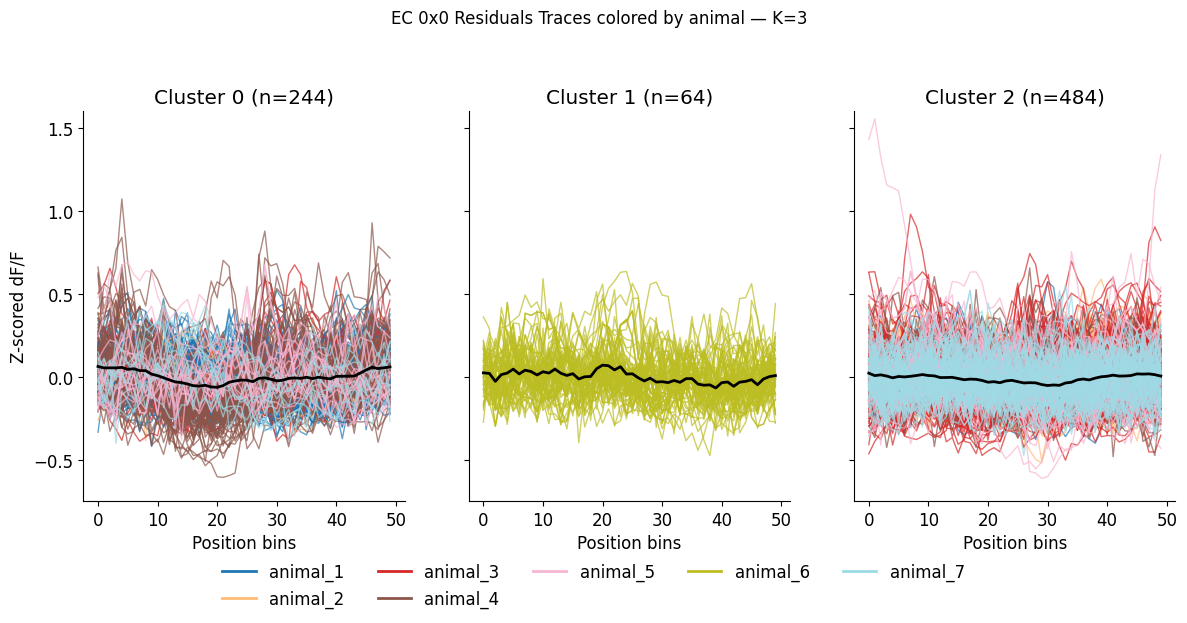

In [ ]:
# model_20_EC_raw_x00 = get_the_tca_model(residual_activity_dict_EC, components=(0,20,0))


def get_r_list(fixed_activity_dict_NDNF_newest, factors_dict_NDNF_newest, min_val_EC, data_to_corr=None):

    r_list_vel = []
    vel_per_animal = []
    for animal in fixed_activity_dict_NDNF_newest:
        for cell in fixed_activity_dict_NDNF_newest[animal]:
            vel = factors_dict_NDNF_newest[animal][data_to_corr][:,:min_val_EC]
            vel_per_animal.append(vel)
            data = fixed_activity_dict_NDNF_newest[animal][cell][:,:min_val_EC]

            print(f"vel.flatten() {vel.flatten().shape}, data.flatten() {data.flatten().shape}")
            r, _ = pearsonr(vel.flatten(), data.flatten())
            r_list_vel.append(r)

    array_data = np.array(vel_per_animal)
    r_dict_vel = {"r_list":r_list_vel,
                  "array_data":array_data}

    return r_dict_vel


data_truncated_array_EC, min_val_EC = get_truncated_to_min_data_array(residual_activity_dict_EC)

r_dict_vel = get_r_list(residual_activity_dict_EC, animal_vel_dict, min_val_EC, data_to_corr="Velocity")
# r_dict_licks = get_r_list(residual_activity_dict_EC, animal_lick_dict, min_val_EC, data_to_corr="Licks")
         


save_path = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/all_cells_truncated_EC_model.pkl'
with open(save_path, 'rb') as f:
    model_20_EC_raw_0x0 = pickle.load(f)

labels_cells_dict_all_K_EC_0x0_raw = get_labels_all_different_Ks_single(model_20_EC_raw_0x0, which_vectors=1)

means_dict_cluster_0x0_EC = plot_reconstructions(labels_cells_dict_all_K_EC_0x0_raw, residual_activity_dict_EC, r_dict_vel, r_dict_vel, prefix="EC 0x0 Raw")

cells_per_animal_dict = get_cells_per_animal_dict(residual_activity_dict_EC)

plot_cluster_traces_by_animal(means_dict_cluster_0x0_EC,
                              residual_activity_dict_EC,
                              cells_per_animal_dict,
                              K=3,
                              ncol=5, spacing=0.2,
                              title_prefix="EC 0x0 Residuals", ylim=(-0.75, 1.6))

vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatte

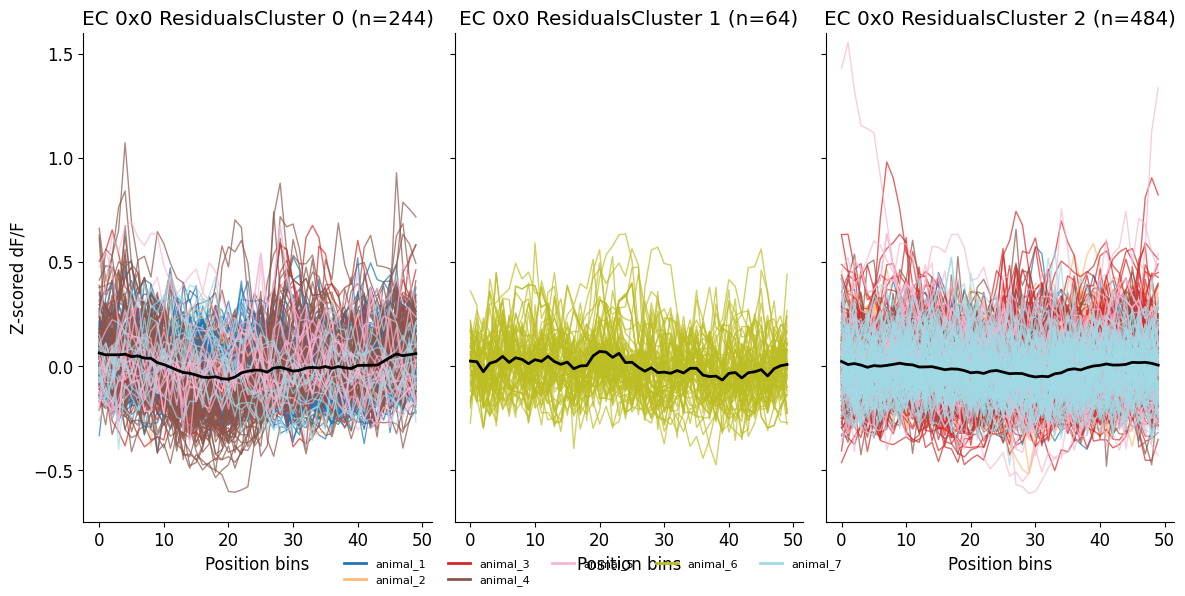

<Figure size 640x480 with 0 Axes>

In [ ]:
# model_20_EC_raw_x00 = get_the_tca_model(residual_activity_dict_EC, components=(0,20,0))


def get_r_list(fixed_activity_dict_NDNF_newest, factors_dict_NDNF_newest, min_val_EC, data_to_corr=None):

    r_list_vel = []
    vel_per_animal = []
    for animal in fixed_activity_dict_NDNF_newest:
        for cell in fixed_activity_dict_NDNF_newest[animal]:
            vel = factors_dict_NDNF_newest[animal][data_to_corr][:,:min_val_EC]
            vel_per_animal.append(vel)
            data = fixed_activity_dict_NDNF_newest[animal][cell][:,:min_val_EC]

            print(f"vel.flatten() {vel.flatten().shape}, data.flatten() {data.flatten().shape}")
            r, _ = pearsonr(vel.flatten(), data.flatten())
            r_list_vel.append(r)

    array_data = np.array(vel_per_animal)
    r_dict_vel = {"r_list":r_list_vel,
                  "array_data":array_data}

    return r_dict_vel


data_truncated_array_EC, min_val_EC, _ = get_truncated_to_min_data_array(residual_activity_dict_EC)

r_dict_vel = get_r_list(residual_activity_dict_EC, animal_vel_dict, min_val_EC, data_to_corr="Velocity")
# r_dict_licks = get_r_list(residual_activity_dict_EC, animal_lick_dict, min_val_EC, data_to_corr="Licks")
         






save_path = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/all_cells_truncated_EC_model.pkl'
with open(save_path, 'rb') as f:
    model_20_EC_raw_0x0 = pickle.load(f)

labels_cells_dict_all_K_EC_0x0_raw = get_labels_all_different_Ks_single(model_20_EC_raw_0x0, which_vectors=1)

means_dict_cluster_0x0_EC = plot_reconstructions(labels_cells_dict_all_K_EC_0x0_raw, residual_activity_dict_EC, r_dict_vel, r_dict_vel, prefix="EC 0x0 Raw")

cells_per_animal_dict = get_cells_per_animal_dict(residual_activity_dict_EC)

plot_cluster_traces_by_animal(means_dict_cluster_0x0_EC,
                              residual_activity_dict_EC,
                              K=3,
                              ncol=5, spacing=0.2,
                              title_prefix="EC 0x0 Residuals", ylim=(-0.75, 1.6))
plt.tight_layout()
plt.show()

(array([48.,  3.,  1.,  6.,  3.,  7.,  0.,  1.,  0., 10.,  6.,  3.,  8.,
         3.,  2.,  2.,  0.,  6.,  1.,  3.,  3., 10.,  0.,  6.,  8.,  1.,
         0.,  2.,  3.,  5.,  4.,  5.,  2.,  7.,  4.,  0.,  3.,  2.,  4.,
         5.,  3.,  1.,  1.,  0.,  0., 14.,  3.,  4., 10.,  3.]),
 array([ 0.  ,  0.98,  1.96,  2.94,  3.92,  4.9 ,  5.88,  6.86,  7.84,
         8.82,  9.8 , 10.78, 11.76, 12.74, 13.72, 14.7 , 15.68, 16.66,
        17.64, 18.62, 19.6 , 20.58, 21.56, 22.54, 23.52, 24.5 , 25.48,
        26.46, 27.44, 28.42, 29.4 , 30.38, 31.36, 32.34, 33.32, 34.3 ,
        35.28, 36.26, 37.24, 38.22, 39.2 , 40.18, 41.16, 42.14, 43.12,
        44.1 , 45.08, 46.06, 47.04, 48.02, 49.  ]),
 <BarContainer object of 50 artists>)

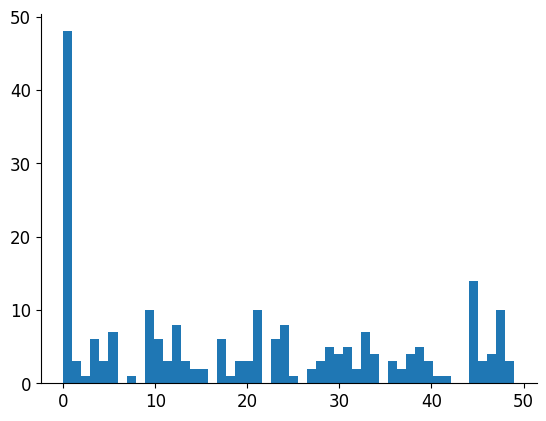

In [ ]:
funky_list = [1, 1, 48, 0, 32, 48, 31, 30, 31, 0, 31, 29, 24, 24, 17, 17, 17, 0, 39, 0, 39, 0, 46, 45, 45, 0, 10, 10, 24, 24, 10, 20, 0, 49, 3, 36, 36, 45, 45, 45, 12, 12, 12, 12, 12, 27, 12, 12, 12, 9, 9, 9, 31, 9, 9, 0, 0, 0, 0, 0, 5, 45, 45, 11, 33, 38, 38, 33, 4, 9, 4, 45, 45, 45, 45, 48, 0, 45, 0, 11, 0, 7, 27, 47, 25, 0, 29, 46, 46, 34, 0, 34, 20, 49, 1, 0, 40, 24, 39, 0, 39, 34, 5, 48, 48, 48, 0, 48, 23, 20, 23, 45, 5, 5, 32, 49, 23, 10, 48, 0, 0, 0, 48, 0, 19, 19, 19, 23, 23, 23, 0, 0, 0, 48, 2, 30, 13, 30, 33, 24, 33, 33, 17, 0, 0, 0, 0, 0, 11, 45, 0, 15, 28, 28, 28, 0, 9, 21, 5, 21, 24, 24, 30, 0, 0, 14, 29, 29, 29, 31, 15, 18, 4, 0, 36, 0, 0, 0, 21, 21, 0, 21, 0, 21, 21, 21, 10, 33, 0, 3, 3, 0, 3, 33, 10, 38, 38, 17, 13, 13, 17, 9, 40, 0, 0, 37, 0, 9, 37, 9, 34, 40, 14, 21, 21, 5, 0, 5, 47, 47, 47, 41, 39, 3, 42, 3]

plt.hist(funky_list, bins=50)

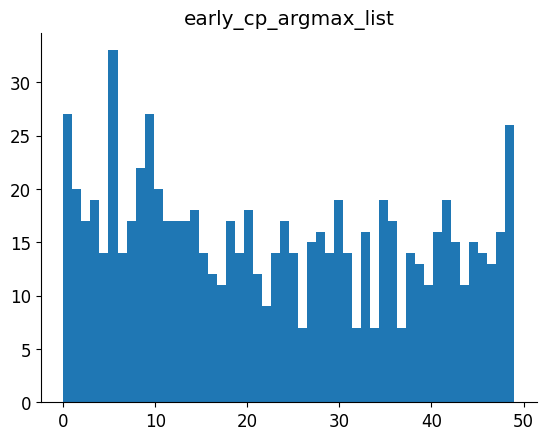

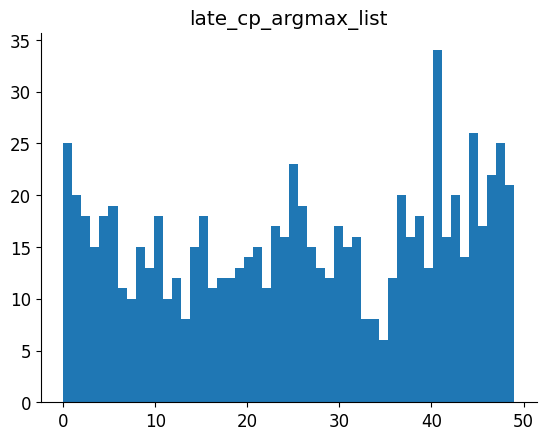

In [ ]:

def get_argmin_argmax_list_learning_celltype(labels, residual_activity_dict_EC, cp_dict_EC):

    early_cp_argmax_list = []
    early_cp_argmin_list = []

    late_cp_argmax_list = []
    late_cp_argmin_list = []

    count = 0

    for idx, animal in enumerate(residual_activity_dict_EC):
        for idt, cell in enumerate(residual_activity_dict_EC[animal]):

            if count in labels:
                early_cp = cp_dict_EC[idx][idt][0]
                late_cp = cp_dict_EC[idx][idt][1]

                data_early = np.mean(residual_activity_dict_EC[animal][cell][:, :early_cp], axis=1)
                data_late = np.mean(residual_activity_dict_EC[animal][cell][:, late_cp:], axis=1)

                early_cp_argmax_list.append(np.argmax(data_early))
                early_cp_argmin_list.append(np.argmin(data_early))

                late_cp_argmax_list.append(np.argmax(data_late))
                late_cp_argmin_list.append(np.argmin(data_late))

            count+=1



    return early_cp_argmax_list, early_cp_argmin_list, late_cp_argmax_list, late_cp_argmin_list



plt.hist(early_cp_argmax_list, bins=50)
plt.title("early_cp_argmax_list")
plt.show()

plt.hist(late_cp_argmax_list, bins=50)
plt.title("late_cp_argmax_list")
plt.show()




        

In [ ]:
save_path = "/Users/michaelfinch/CA1_interneuron_model/datasets/tt_pkl.pkl"

with open(save_path, 'rb') as f:
    important_dict = pickle.load(f)


print(important_dict.keys())

dict_keys(['TT_list', 'NDNF_activity_list', 'cp_list_NDNF'])


In [ ]:
"max_loc"=13
"min_loc"=46
"max_amp"=3.0
"min_amp"=-0.5

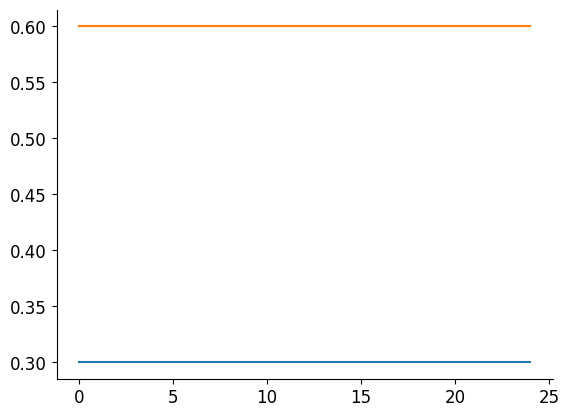

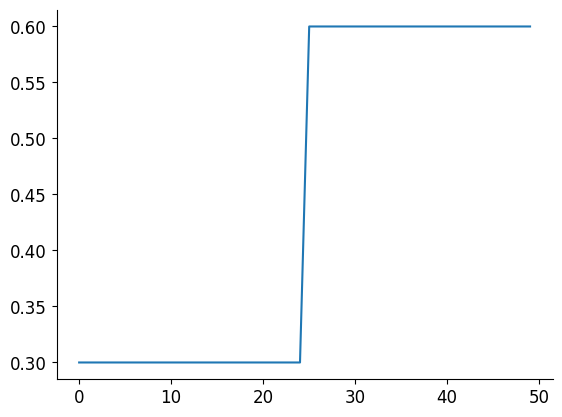

In [ ]:
p = np.full(25, 0.3)
q = np.full(25, 0.6)

v = np.hstack([p, q])

plt.plot(p)
plt.plot(q)
plt.show()

plt.plot(v)

Text(0, 0.5, 'Synthetic Z-Score DF/F')

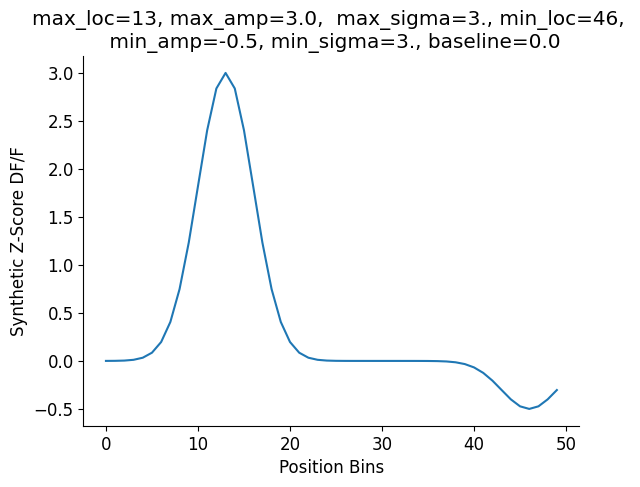

In [ ]:

def two_gaussian_trace(n=50, max_loc=13, max_amp=3.0,  max_sigma=3.0, min_loc=46, min_amp=-0.5, min_sigma=4.0, baseline=0.0):

    x = np.arange(n)
    y = np.full(n, baseline, dtype=float)

    y += max_amp * np.exp(-0.5 * ((x - max_loc) / max_sigma)**2)
    y += min_amp * np.exp(-0.5 * ((x - min_loc) / min_sigma)**2)

    return y

y = two_gaussian_trace(n=50, max_loc=13, max_amp=3.0,  max_sigma=3., min_loc=46, min_amp=-0.5, min_sigma=3., baseline=0.0)

plt.plot(y)
plt.title("max_loc=13, max_amp=3.0,  max_sigma=3., min_loc=46, \n min_amp=-0.5, min_sigma=3., baseline=0.0")
plt.xlabel("Position Bins")
plt.ylabel("Synthetic Z-Score DF/F")


# max_fwhm = 8
# min_fwhm = 10
# max_sigma = max_fwhm / 2.355
# min_sigma = min_fwhm / 2.355




576


In [131]:
save_path = "/Users/michaelfinch/CA1_interneuron_model/misc/some_things_dict.pkl"

with open(save_path, 'rb') as f:
    some_things_dict = pickle.load(f)

print(some_things_dict.keys())

dict_keys(['overall_activity_list_all', 'cells_for_cluster_list', 'expression_list_early_overall', 'expression_list_late_overall', 'activity_list_early_overall', 'activity_list_late_overall'])


In [132]:
overall_activity_list_all = some_things_dict["overall_activity_list_all"]
overall_activity_list_all_array = np.array(overall_activity_list_all)

cells_for_cluster_list = some_things_dict["cells_for_cluster_list"]
cells_for_cluster_array = np.array(cells_for_cluster_list)

expression_list_early_overall = some_things_dict["expression_list_early_overall"]
expression_array_early_overall = np.array(expression_list_early_overall)

expression_list_late_overall = some_things_dict["expression_list_late_overall"]
expression_array_late_overall = np.array(expression_list_late_overall)

activity_list_early_overall = some_things_dict["activity_list_early_overall"]
activity_array_early_overall = np.array(activity_list_early_overall)

activity_list_late_overall = some_things_dict["activity_list_late_overall"]
activity_array_late_overall = np.array(activity_list_late_overall)


cells_for_cluster_array [  0   0   0   1   1   1   2   2   2   2   3   3   3   4   4   4   5   5
   5   7   7   7   7   7   8   8   8   9   9   9  10  10  10  11  11  11
  12  12  12  13  13  13  14  14  14  15  15  15  16  16  16  17  17  17
  18  18  18  18  19  19  19  20  20  20  20  21  21  21  22  22  22  23
  23  23  24  24  24  25  25  25  25  25  25  26  26  26  27  27  27  28
  28  28  29  29  29  29  29  30  30  30  30  34  34  34  36  36  37  37
  37  38  38  38  39  39  39  40  40  40  41  41  41  41  64  64  64  65
  65  65  66  66  66  66  68  68  68  69  69  69  69  70  70  70  70  71
  71  71  72  72  72  73  73  73  74  74  74  75  75  75  75  75  75  76
  76  76  77  77  77  78  78  78  79  79  79  80  80  80  82  82  82  84
  84  84  85  85  85  86  86  86  87  87  87  89  89  89  91  91  91  96
  96  96  96  97  97  97  98  98  98 100 100 100 101 101 101 104 104 104
 113 113 113 114 114 114 115 115 115 116 116 116 117 117 117 119 119 119
 122 122 122 123 123 123 12

/var/folders/hl/zfn0lkv15xx80f47pqqz8p9c0000gn/T/ipykernel_23369/109101948.py:119: RuntimeWarning: Mean of empty slice
  cell_traces_late.append(   np.nanmean(activity_array_late_overall[rows, :], axis=0))
/var/folders/hl/zfn0lkv15xx80f47pqqz8p9c0000gn/T/ipykernel_23369/109101948.py:118: RuntimeWarning: Mean of empty slice
  cell_traces_early.append(  np.nanmean(activity_array_early_overall[rows, :], axis=0))
/var/folders/hl/zfn0lkv15xx80f47pqqz8p9c0000gn/T/ipykernel_23369/109101948.py:118: RuntimeWarning: Mean of empty slice
  cell_traces_early.append(  np.nanmean(activity_array_early_overall[rows, :], axis=0))
/var/folders/hl/zfn0lkv15xx80f47pqqz8p9c0000gn/T/ipykernel_23369/109101948.py:119: RuntimeWarning: Mean of empty slice
  cell_traces_late.append(   np.nanmean(activity_array_late_overall[rows, :], axis=0))
/var/folders/hl/zfn0lkv15xx80f47pqqz8p9c0000gn/T/ipykernel_23369/109101948.py:118: RuntimeWarning: Mean of empty slice
  cell_traces_early.append(  np.nanmean(activity_array_

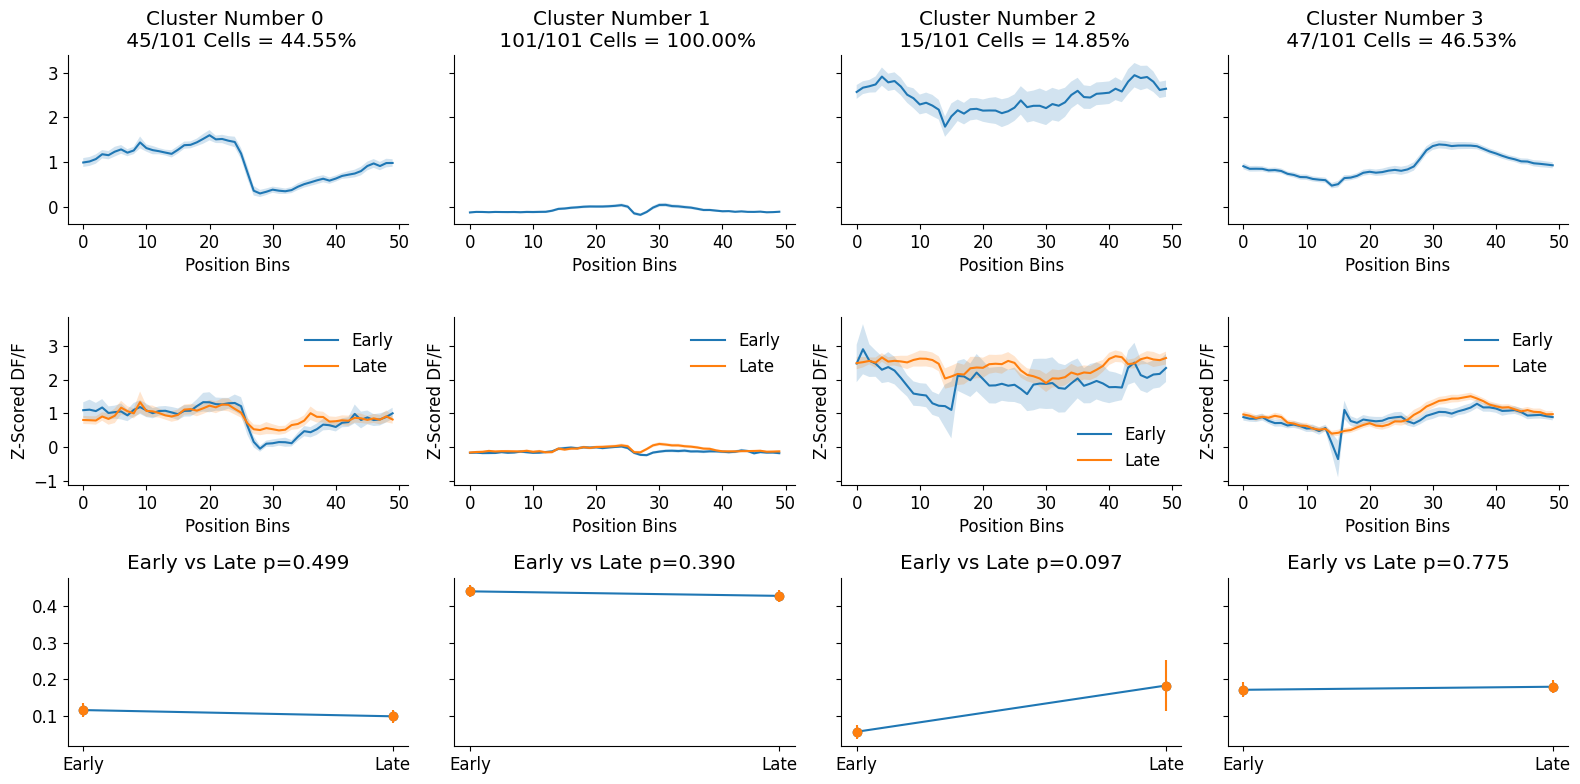

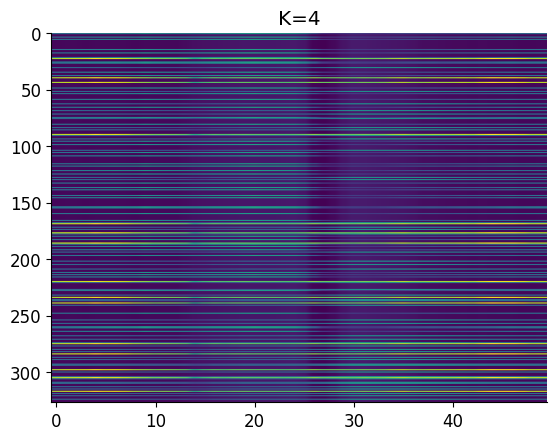

In [168]:
from sklearn.cluster import KMeans
import numpy as np

from scipy.stats import ttest_rel

def find_elbow(K, mse):
    # normalize
    x = (K - K.min()) / (K.max() - K.min())
    y = (mse - mse.min()) / (mse.max() - mse.min())

    # line between endpoints
    p1 = np.array([x[0], y[0]])
    p2 = np.array([x[-1], y[-1]])

    # distance from each point to the line
    distances = []
    for xi, yi in zip(x, y):
        p = np.array([xi, yi])
        d = np.linalg.norm(np.cross(p2 - p1, p1 - p)) / np.linalg.norm(p2 - p1)
        distances.append(d)

    distances = np.array(distances)
    elbow_idx = np.argmax(distances)
    return K[elbow_idx], distances


def trial_types_for_given_k(some_things_dict, k=None):

    overall_activity_list_all = some_things_dict["overall_activity_list_all"]
    overall_activity_list_all_array = np.array(overall_activity_list_all)

    cells_for_cluster_list = some_things_dict["cells_for_cluster_list"]
    cells_for_cluster_array = np.array(cells_for_cluster_list)

    print(f"cells_for_cluster_array {cells_for_cluster_array}")

    expression_list_early_overall = some_things_dict["expression_list_early_overall"]
    expression_array_early_overall = np.array(expression_list_early_overall)

    expression_list_late_overall = some_things_dict["expression_list_late_overall"]
    expression_array_late_overall = np.array(expression_list_late_overall)

    activity_list_early_overall = some_things_dict["activity_list_early_overall"]
    activity_array_early_overall = np.array(activity_list_early_overall)

    activity_list_late_overall = some_things_dict["activity_list_late_overall"]
    activity_array_late_overall = np.array(activity_list_late_overall)

    mse_list = []

    labels_list = []

    overall_unique_cells = np.unique(cells_for_cluster_array)
    n_cells = len(overall_unique_cells)

    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')

    labels = kmeans.fit_predict(overall_activity_list_all_array)

    labels_list.append(labels)

    empty_arrray = np.empty(overall_activity_list_all_array.shape)

    u = np.unique(labels)

    fig, axs = plt.subplots(3, len(u), figsize=(4*len(u), 8), sharey='row')

    # Force axs to always be 2D: (3, n_clusters)
    axs = np.atleast_2d(axs)
    if axs.shape[0] != 3:
        axs = axs.reshape(3, -1)

    for i in u:
        # labels_for_cluster = np.where(labels==i)[0]

        # print(f"cells_for_cluster_array by cluster {cells_for_cluster_array[labels_for_cluster]}")
        
        # mean_activity_in_cluster = np.mean(overall_activity_list_all_array[labels_for_cluster,:], axis=0)
        # sem_activity_in_cluster = sem(overall_activity_list_all_array[labels_for_cluster,:], axis=0)

        # mean_activity_in_cluster_early = np.nanmean(activity_array_early_overall[labels_for_cluster,:], axis=0)
        # mean_activity_in_cluster_late = np.nanmean(activity_array_late_overall[labels_for_cluster,:], axis=0)

        # sem_activity_in_cluster_early = sem(activity_array_early_overall[labels_for_cluster,:], axis=0, nan_policy='omit')
        # sem_activity_in_cluster_late = sem(activity_array_late_overall[labels_for_cluster,:], axis=0, nan_policy='omit')

        # num_cells_expressed = np.array(cells_for_cluster_list)[labels_for_cluster]

        # unique_cells = np.unique(num_cells_expressed)

        # expression_array_early_overall_cluster = expression_array_early_overall[labels_for_cluster]
        # expression_array_late_overall_cluster = expression_array_late_overall[labels_for_cluster]

        # mean_expression_in_cluster_early = np.mean(expression_array_early_overall_cluster)
        # mean_expression_in_cluster_late = np.mean(expression_array_late_overall_cluster)
        # sem_expression_in_cluster_early = sem(expression_array_early_overall_cluster)
        # sem_expression_in_cluster_late = sem(expression_array_late_overall_cluster)

        labels_for_cluster = np.where(labels == i)[0]

        # rows and their cell ids within this cluster
        cell_ids_in_cluster = cells_for_cluster_array[labels_for_cluster]
        unique_cell_ids = np.unique(cell_ids_in_cluster)

        # ---- build ONE trace per cell (overall / early / late) ----
        cell_traces_overall = []
        cell_traces_early   = []
        cell_traces_late    = []

        cell_expr_early = []
        cell_expr_late  = []

        for cid in unique_cell_ids:
            rows = labels_for_cluster[cell_ids_in_cluster == cid]   # indices into the big arrays

            # average within-cell first (this is the key)
            cell_traces_overall.append(np.nanmean(overall_activity_list_all_array[rows, :], axis=0))
            cell_traces_early.append(  np.nanmean(activity_array_early_overall[rows, :], axis=0))
            cell_traces_late.append(   np.nanmean(activity_array_late_overall[rows, :], axis=0))

            # expression: also average within-cell (so each cell counts once)
            cell_expr_early.append(np.nanmean(expression_array_early_overall[rows]))
            cell_expr_late.append( np.nanmean(expression_array_late_overall[rows]))

        cell_traces_overall = np.asarray(cell_traces_overall)
        cell_traces_early   = np.asarray(cell_traces_early)
        cell_traces_late    = np.asarray(cell_traces_late)

        cell_expr_early = np.asarray(cell_expr_early)
        cell_expr_late  = np.asarray(cell_expr_late)

        # ---- now compute mean/SEM across CELLS (not rows) ----
        mean_activity_in_cluster = np.nanmean(cell_traces_overall, axis=0)
        sem_activity_in_cluster  = sem(cell_traces_overall, axis=0, nan_policy='omit')

        mean_activity_in_cluster_early = np.nanmean(cell_traces_early, axis=0)
        mean_activity_in_cluster_late  = np.nanmean(cell_traces_late, axis=0)

        sem_activity_in_cluster_early = sem(cell_traces_early, axis=0, nan_policy='omit')
        sem_activity_in_cluster_late  = sem(cell_traces_late, axis=0, nan_policy='omit')

        # expression per cell
        mean_expression_in_cluster_early = np.nanmean(cell_expr_early)
        mean_expression_in_cluster_late  = np.nanmean(cell_expr_late)
        sem_expression_in_cluster_early  = sem(cell_expr_early, nan_policy='omit')
        sem_expression_in_cluster_late   = sem(cell_expr_late,  nan_policy='omit')

        # paired test across CELLS
        t, p = ttest_rel(cell_expr_early, cell_expr_late, nan_policy='omit')

        # your title counts now make sense:
        n_unique_cells_in_cluster = len(unique_cell_ids)


        empty_arrray[labels_for_cluster,:] = mean_activity_in_cluster

        axs[0,i].plot(mean_activity_in_cluster)
        axs[0,i].fill_between(range(len(mean_activity_in_cluster)), mean_activity_in_cluster-sem_activity_in_cluster, mean_activity_in_cluster+sem_activity_in_cluster, alpha=0.2)
        axs[0,i].set_title(f"Cluster Number {i} \n {n_unique_cells_in_cluster}/{n_cells} Cells = {(n_unique_cells_in_cluster/n_cells)*100:.2f}%")
        axs[0,i].set_xlabel(f"Z-Scored DF/F")
        axs[0,i].set_xlabel(f"Position Bins")

        axs[1,i].plot(mean_activity_in_cluster_early, label="Early")
        axs[1,i].plot(mean_activity_in_cluster_late, label="Late")
        axs[1,i].fill_between(range(len(mean_activity_in_cluster_early)), mean_activity_in_cluster_early+sem_activity_in_cluster_early, mean_activity_in_cluster_early-sem_activity_in_cluster_early, alpha=0.2)
        axs[1,i].fill_between(range(len(mean_activity_in_cluster_late)), mean_activity_in_cluster_late+sem_activity_in_cluster_late, mean_activity_in_cluster_late-sem_activity_in_cluster_late, alpha=0.2)
        axs[1,i].set_ylabel(f"Z-Scored DF/F")
        axs[1,i].set_xlabel(f"Position Bins")
        axs[1,i].legend()

        x = [0.1, 0.9]

        # t, p = ttest_rel(expression_array_early_overall_cluster, expression_array_late_overall_cluster)

        means_list = [mean_expression_in_cluster_early, mean_expression_in_cluster_late]
        
        sems_list = [sem_expression_in_cluster_early, sem_expression_in_cluster_late]

        axs[2,i].plot(x, means_list, marker='o')
        axs[2, i].errorbar(x, means_list, yerr=sems_list, fmt='o')
        axs[2,i].set_title(f"Early vs Late p={p:.3f}")
        axs[2,i].set_xticks(x, ["Early", "Late"])


    plt.tight_layout()
    plt.show()

    mse_list.append(np.mean(np.square(empty_arrray-overall_activity_list_all_array)))

    plt.imshow(empty_arrray, aspect='auto')
    plt.title(f"K={k}")
    plt.show()

    return mse_list


mse_list = trial_types_for_given_k(some_things_dict, k=4)

def plot_mse_elbow(mse_list, title=None):

    K = np.arange(1, len(mse_list)+1)

    mse_array = np.array(mse_list)

    elbow_k, distances = find_elbow(K, mse_array)

    plt.figure()
    plt.plot(K, mse_array, '-o')
    plt.title(title)
    plt.axvline(elbow_k+1, color='r', linestyle='--', label=f'Elbow K={elbow_k}')
    plt.legend()
    plt.show()







46


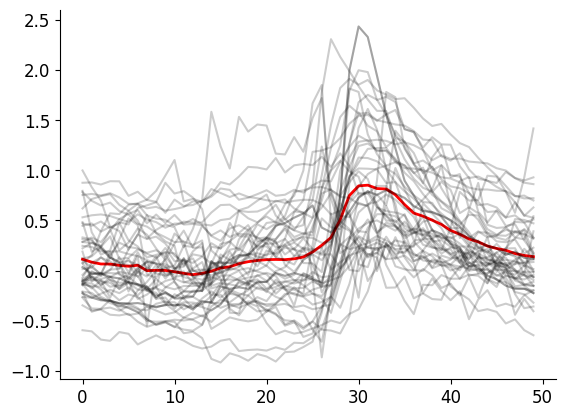

In [81]:
def find_max_loc_middle(overall_activity_list_all):
    i_list = []
    cell_list_late_peak = []
    for i in range(overall_activity_list_all.shape[0]):
        max_loc = np.argmax(overall_activity_list_all[i,:])
        if 25<max_loc<35:
            i_list.append(overall_activity_list_all[i,:])
            cell_list_late_peak.append(i)

    print(len(i_list))

    i_array = np.array(i_list)
    i_array.shape
    mean_i_array = np.mean(i_array, axis=0)
    plt.plot(mean_i_array, color="r", linewidth=2)
    for j in range(i_array.shape[0]):
        plt.plot(i_array[j,:], color='k', alpha=0.2)

    plt.show()

    return np.array(cell_list_late_peak)


cell_list_late_peak = find_max_loc_middle(middle_expressed_activity_array)



In [98]:
middle_expressed_expression_array_early_of_interest = middle_expressed_expression_array_early[cell_list_late_peak]
middle_expressed_expression_array_late_of_interest = middle_expressed_expression_array_late[cell_list_late_peak]

from scipy.stats import ttest_rel
_, p = ttest_rel(middle_expressed_expression_array_early_of_interest, middle_expressed_expression_array_late_of_interest)
print(p)

print(np.mean(middle_expressed_expression_array_early_of_interest), np.mean(middle_expressed_expression_array_late_of_interest))

0.09847844571571798
0.23629303882334182 0.2794910384817059


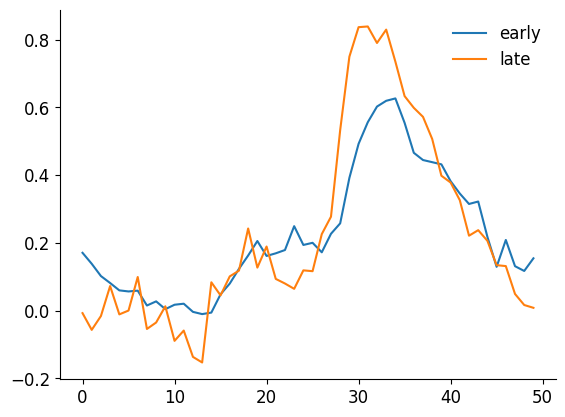

In [95]:
x = np.nanmean(middle_expressed_activity_early_array[cell_list_late_peak,:], axis=0)
y = np.nanmean(middle_expressed_activity_late_array[cell_list_late_peak,:], axis=0)

plt.plot(x, label='early')
plt.plot(y, label='late')
plt.legend()

In [35]:
save_path= "/Users/michaelfinch/CA1_interneuron_model/misc/generative_EC_NDNF_SST_nested_number_6_velFbetaTinputF.pkl"
with open(save_path, 'rb') as f:
    generative_EC_NDNF_SST_nested_number_6_velFbetaTinputF = pickle.load(f)

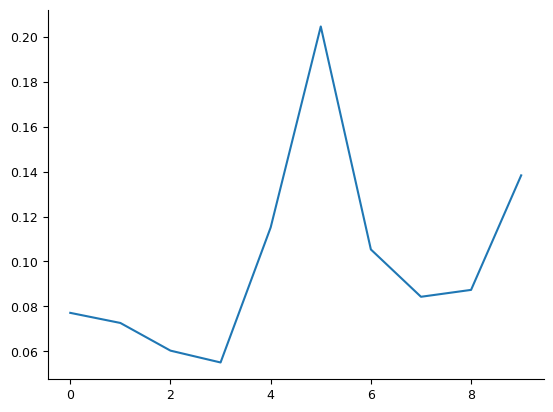

In [36]:
plt.plot(generative_EC_NDNF_SST_nested_number_6_velFbetaTinputF)

In [ ]:
cp_

In [ ]:


for animal in residual_activity_dict_SST:
    for cell in residual_activity_dict_SST[animal]:

        mean_data = np.mean(residual_activity_dict_SST[animal[cell], axis=1)


In [ ]:
from scipy.stats import kurtosis

def make_trace(sig_max, sig_min):
    y = np.full(n, baseline, dtype=float)
    y += max_amp * np.exp(-0.5 * ((x - max_loc) / sig_max) ** 2)
    y += min_amp * np.exp(-0.5 * ((x - min_loc) / sig_min) ** 2)
    return y

y = make_trace(sig_max, sig_min)

y_centered = y - baseline
k = kurtosis(y_centered, fisher=True, bias=False)
print(k)

In [ ]:
overall_activity_list_all_array = np.array(overall_activity_list_all)

AttributeError: 'list' object has no attribute 'shape'

In [34]:
x = overall_activity_list_all[i_array]
len(x)

TypeError: only integer scalar arrays can be converted to a scalar index

In [176]:
data = overall_activity_list[0]
rounded_data = np.round(data, decimals=1) 
print(rounded_data)
from scipy import stats

# find mode of entire array
result = stats.mode(rounded_data, keepdims=True)
print(result.mode)

vals, counts = np.unique(rounded_data, return_counts=True)
for i in range(len(vals)):
    print(f"vals[i] {vals[i]} counts[i] {counts[i]}")

[0.3 0.3 0.3 0.3 0.3 0.3 0.2 0.2 0.3 0.3 0.5 0.5 0.5 0.5 0.6 0.5 0.5 0.5
 0.5 0.6 0.6 0.8 0.8 0.9 1.1 1.  0.8 0.2 0.1 0.  0.  0.  0.1 0.2 0.3 0.4
 0.5 0.5 0.4 0.5 0.5 0.6 0.6 0.6 0.7 0.8 0.8 0.8 0.8 0.7]
[0.5]
vals[i] 0.0 counts[i] 3
vals[i] 0.1 counts[i] 2
vals[i] 0.2 counts[i] 4
vals[i] 0.3 counts[i] 9
vals[i] 0.4 counts[i] 2
vals[i] 0.5 counts[i] 12
vals[i] 0.6 counts[i] 6
vals[i] 0.7 counts[i] 2
vals[i] 0.8 counts[i] 7
vals[i] 0.9 counts[i] 1
vals[i] 1.0 counts[i] 1
vals[i] 1.1 counts[i] 1


In [196]:
save_path = f"/Users/michaelfinch/CA1_interneuron_model/misc/reconstructed_data_EC.pkl"
with open(save_path, 'rb') as f:
    final_activity_dict_SST = pickle.load(f)


residual_list_SST = []

for animal in final_activity_dict_SST:
    for cell in final_activity_dict_SST[animal]:
        residual_list_SST.append(final_activity_dict_SST[animal][cell])

print(len(residual_list_SST))

792


2376.0 792


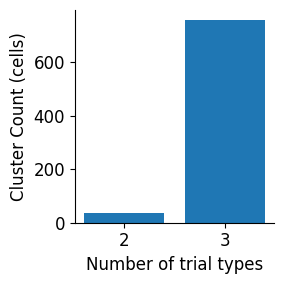

In [ ]:
cell=0

sums_list = []

number_trial_types = []

ta_activity_dict_for_cluster = {}

for cell in range(len(important_dict["TT_list"])):

    labels = important_dict["TT_list"][cell]["labels_dict"]["clusters_chosen_3"]

    early_cp=important_dict["cp_list_NDNF"][cell][0]
    late_cp=important_dict["cp_list_NDNF"][cell][1]

    label_values = np.unique(labels)

    number_trial_types.append(len(label_values))

    activity_pattern_cell = important_dict["NDNF_activity_list"][cell]

    ta_activity_dict_for_cluster_cell = {}

    for i in label_values:

        trial_type_0_loc = np.where(labels==i)[0]

        overall_expression_prob = len(trial_type_0_loc) / activity_pattern_cell.shape[1]

        den = len(trial_type_0_loc)

        if den == 0:
            print("no zero cells")
            print(labels)

        tt0_early = trial_type_0_loc<early_cp
        tt0_indices_early = trial_type_0_loc[tt0_early]
        total_trials_early = len(tt0_early)
        successes_early = np.sum(tt0_early) ## this is a count of early block successes

        activity_pattern_early = activity_pattern_cell[:,tt0_indices_early]

        tt0_middle = (trial_type_0_loc >= early_cp) & (trial_type_0_loc <  late_cp)
        total_trials_middle = len(tt0_middle)
        successes_middle = np.sum(tt0_middle)
        tt0_indices_middle = trial_type_0_loc[tt0_middle]
        activity_pattern_middle = activity_pattern_cell[:,tt0_indices_middle]

        tt0_late   = trial_type_0_loc >= late_cp
        total_trials_late = len(tt0_late)
        successes_late = np.sum(tt0_late)
        tt0_indices_late = trial_type_0_loc[tt0_late]
        activity_pattern_late = activity_pattern_cell[:,tt0_indices_late]

        ta_activity_early = np.mean(activity_pattern_early, axis=1)
        ta_activity_middle = np.mean(activity_pattern_middle, axis=1)
        ta_activity_late = np.mean(activity_pattern_late, axis=1)

        middle_num_trials = late_cp-early_cp
        late_num_trials = activity_pattern_cell.shape[1] - late_cp

        sum = early_cp+middle_num_trials+late_num_trials


        if activity_pattern_cell.shape[1] != sum:
            raise ValueError("wrong")

        expression_prob_early = successes_early / early_cp
        expression_prob_middle = successes_middle / middle_num_trials
        expression_prob_late = successes_late / late_num_trials

        # expression_prob_early = successes_early / total_trials_early
        # expression_prob_middle = successes_middle / total_trials_middle
        # expression_prob_late = successes_late / total_trials_late

        act_dict = {"cluster_expression": overall_expression_prob,
                    "early":ta_activity_early,
                    "middle":ta_activity_middle,
                    "late":ta_activity_late,
                    "early_expression":expression_prob_early,
                    "middle_expression":expression_prob_middle,
                    "late_expression": expression_prob_late,
                    "n_early": int(successes_early),
                    "n_middle": int(successes_middle),
                    "n_late": int(successes_late),}

        ta_activity_dict_for_cluster_cell[i] = act_dict

        if np.isnan(expression_prob_early):
            expression_prob_early = 0.

        if np.isnan(expression_prob_middle):
            expression_prob_middle = 0.

        if np.isnan(expression_prob_late):
            expression_prob_late = 0.

        all_list = [expression_prob_early, expression_prob_middle, expression_prob_late]
        sums = np.sum(all_list)

        sums_list.append(sums)


    ta_activity_dict_for_cluster[cell] = ta_activity_dict_for_cluster_cell

print(np.sum(sums_list), len(important_dict["TT_list"]))

vals, counts = np.unique(number_trial_types, return_counts=True)

plt.figure(figsize=(3,3))
plt.bar(vals, counts)
plt.xticks(vals)
plt.xlabel("Number of trial types")
plt.ylabel("Cluster Count (cells)")
plt.tight_layout()
plt.show()
# plt.plot(number_trial_types)

np.sum(p_early_norm) 1.0 np.sum(p_early) 1.0
np.sum(p_early_norm) 1.0 np.sum(p_early) 1.0
np.sum(p_early_norm) 1.0 np.sum(p_early) 1.0
(50, 80)
np.sum(p_early_norm) 1.0 np.sum(p_early) 1.0
np.sum(p_early_norm) 1.0 np.sum(p_early) 1.0
np.sum(p_early_norm) 1.0 np.sum(p_early) 1.0
(50, 80)
np.sum(p_early_norm) 1.0 np.sum(p_early) 1.0
np.sum(p_early_norm) 1.0 np.sum(p_early) 1.0
np.sum(p_early_norm) 1.0 np.sum(p_early) 1.0
(50, 80)
np.sum(p_early_norm) 1.0 np.sum(p_early) 1.0
np.sum(p_early_norm) 1.0000000000000002 np.sum(p_early) 0.9999999999999999
np.sum(p_early_norm) 1.0 np.sum(p_early) 1.0
(50, 80)
np.sum(p_early_norm) 1.0 np.sum(p_early) 1.0
np.sum(p_early_norm) 1.0 np.sum(p_early) 1.0
np.sum(p_early_norm) 1.0 np.sum(p_early) 1.0
(50, 80)
np.sum(p_early_norm) 1.0 np.sum(p_early) 1.0
np.sum(p_early_norm) 1.0 np.sum(p_early) 1.0
np.sum(p_early_norm) 1.0 np.sum(p_early) 1.0
(50, 80)
np.sum(p_early_norm) 1.0 np.sum(p_early) 1.0
np.sum(p_early_norm) 1.0 np.sum(p_early) 1.0
np.sum(p_early_n

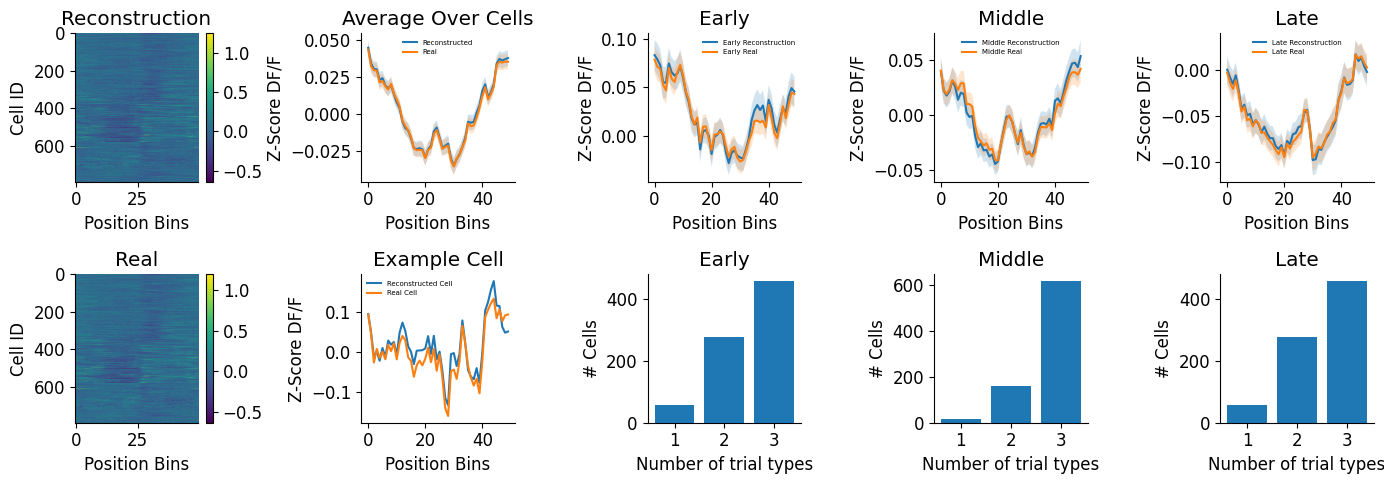

In [ ]:
data_list = [] 
ta_real_data_list = []   

early_data_list = [] 
middle_data_list = [] 
late_data_list = [] 

early_data_list_reco = [] 
middle_data_list_reco = [] 
late_data_list_reco = []

number_trials_dict = {"early": [],
                      "middle": [],
                      "late": [],}

for this_cell in range(len(important_dict["NDNF_activity_list"])):

    activity_pattern_cell = important_dict["NDNF_activity_list"][this_cell]

    labels = important_dict["TT_list"][this_cell]["labels_dict"]["clusters_chosen_3"]
    early_cp, late_cp = important_dict["cp_list_NDNF"][this_cell]

    labels_dict = {"early":labels[:early_cp],
                   "middle":labels[early_cp:late_cp],
                   "late":labels[:early_cp]}


    cell_dict = ta_activity_dict_for_cluster[this_cell]
    clusters = np.array(sorted(cell_dict.keys()))  # make it indexable

    p_early= []

    for c in clusters:
        p = np.array(cell_dict[c]["early_expression"])
        p_early.append(p)


    s= np.array(p_early).sum()
    if s == 0:
        raise ValueError("sum of 0")

    p_early = p_early / s

    rng = np.random.default_rng(seed=4)
    early_cluster_per_trial = rng.choice(
        clusters,
        size=early_cp,
        replace=True,
        p=p_early)

    middle_num_trials = late_cp-early_cp
    late_num_trials = activity_pattern_cell.shape[1] - late_cp

    num_trials_dict = {"early":early_cp,
                        "middle":middle_num_trials,
                        "late":late_num_trials}

    empty_cell_final_list = []


    rng = np.random.default_rng(seed=4)

    for learning_phase in num_trials_dict:

        labels_phase = labels_dict[learning_phase]

        number_trials_dict[learning_phase].append(len(np.unique(labels_phase)))


        p_early= []

        for c in clusters:
            p = np.array(cell_dict[c][f"{learning_phase}_expression"])
            p_early.append(p)

        s= np.array(p_early).sum()
        if s == 0:
            raise ValueError("sum of 0")

        p_early_norm = p_early / s

        print(f"np.sum(p_early_norm) {np.sum(p_early_norm)} np.sum(p_early) {np.sum(p_early)}")

        early_cluster_per_trial = rng.choice(
            clusters,
            size=num_trials_dict[learning_phase],
            replace=True,
            p=p_early_norm)

        empty_cell = np.empty((50, num_trials_dict[learning_phase]))

        for cluster in clusters:
            zero_data = np.where(early_cluster_per_trial==cluster)[0]
            empty_cell[:,zero_data] = cell_dict[cluster][learning_phase][:,None]

        empty_cell_final_list.append(empty_cell)


    empty_cell_final_array = np.hstack(empty_cell_final_list)
    print(empty_cell_final_array.shape)

    early_data_list_reco.append(np.mean(empty_cell_final_array[:,:early_cp], axis=1))
    middle_data_list_reco.append(np.mean(empty_cell_final_array[:,early_cp:late_cp], axis=1))
    late_data_list_reco.append(np.mean(empty_cell_final_array[:,late_cp:], axis=1))

    data_list.append(np.mean(empty_cell_final_array, axis=1))

    ta_real_data_list.append(np.mean(activity_pattern_cell, axis=1))

    early_data_list.append(np.mean(activity_pattern_cell[:,:early_cp], axis=1))
    middle_data_list.append(np.mean(activity_pattern_cell[:,early_cp:late_cp], axis=1))
    late_data_list.append(np.mean(activity_pattern_cell[:,late_cp:], axis=1))


fig, axs= plt.subplots(2,5, figsize=(14,5))

data_array = np.array(data_list)
im = axs[0,0].imshow(data_array, aspect='auto')
axs[0,0].set_title("Reconstruction")
axs[0,0].set_ylabel("Cell ID")
fig.colorbar(im, ax = axs[0,0])

ta_real_data_array = np.array(ta_real_data_list)
im = axs[1,0].imshow(ta_real_data_array, aspect='auto')
axs[1,0].set_title("Real")
axs[1,0].set_ylabel("Cell ID")
fig.colorbar(im, ax = axs[1,0])

data_array_mean = np.mean(data_array, axis=0)
data_array_sem = sem(data_array, axis=0)

axs[0,1].plot(data_array_mean, label="Reconstructed")
axs[0,1].fill_between(range(len(data_array_mean)), data_array_mean+data_array_sem, data_array_mean-data_array_sem, alpha=0.2)
axs[0,1].set_title("Average Over Cells")

average_actual_array = np.mean(ta_real_data_array, axis=0)
sem_actual_array = sem(ta_real_data_array, axis=0)
axs[0,1].fill_between(range(len(average_actual_array)), average_actual_array+sem_actual_array, average_actual_array-sem_actual_array, alpha=0.2)
axs[0,1].plot(average_actual_array, label="Real")
axs[0,1].legend(fontsize=5)

axs[1,1].plot(data_array[8,:], label=f"Reconstructed Cell")
axs[1,1].plot(ta_real_data_array[8,:], label=f"Real Cell")
axs[1,1].set_title("Example Cell")
axs[1,1].legend(fontsize=5)
axs[1,1].set_xlabel("Position Bins")
axs[1,1].set_ylabel("Z-Score DF/F")

axs[0,0].set_xlabel("Position Bins")
axs[0,1].set_xlabel("Position Bins")
axs[1,0].set_xlabel("Position Bins")
axs[1,1].set_xlabel("Position Bins")

axs[0,2].set_xlabel("Position Bins")
axs[0,3].set_xlabel("Position Bins")
axs[0,4].set_xlabel("Position Bins")

axs[0,1].set_ylabel("Z-Score DF/F")
axs[0,2].set_ylabel("Z-Score DF/F")
axs[0,3].set_ylabel("Z-Score DF/F")
axs[0,4].set_ylabel("Z-Score DF/F")



early_data_array = np.array(early_data_list) 
middle_data_array = np.array(middle_data_list)
late_data_array = np.array(late_data_list)

early_data_array_reco = np.array(early_data_list_reco) 
middle_data_array_reco = np.array(middle_data_list_reco)
late_data_array_reco = np.array(late_data_list_reco)

mean_early_data_array_reco = np.mean(early_data_array_reco, axis=0)
mean_middle_data_array_reco = np.mean(middle_data_array_reco, axis=0)
mean_late_data_array_reco = np.mean(late_data_array_reco, axis=0)

sem_early_data_array_reco = sem(early_data_array_reco, axis=0)
sem_middle_data_array_reco = sem(middle_data_array_reco, axis=0)
sem_late_data_array_reco = sem(late_data_array_reco, axis=0)

mean_early_data_array = np.mean(early_data_array, axis=0)
mean_middle_data_array = np.mean(middle_data_array, axis=0)
mean_late_data_array = np.mean(late_data_array, axis=0)

sem_early_data_array = sem(early_data_array, axis=0)
sem_middle_data_array = sem(middle_data_array, axis=0)
sem_late_data_array = sem(late_data_array, axis=0)

axs[0,2].plot(mean_early_data_array_reco, label="Early Reconstruction")
axs[0,2].fill_between(range(len(mean_early_data_array_reco)), mean_early_data_array_reco+sem_early_data_array_reco, mean_early_data_array_reco-sem_early_data_array_reco, alpha=0.2)

axs[0,3].plot(mean_middle_data_array_reco, label="Middle Reconstruction")
axs[0,3].fill_between(range(len(mean_middle_data_array_reco)), mean_middle_data_array_reco+sem_middle_data_array_reco, mean_middle_data_array_reco-sem_middle_data_array_reco, alpha=0.2)

axs[0,4].plot(mean_late_data_array_reco, label="Late Reconstruction")
axs[0,4].fill_between(range(len(mean_late_data_array_reco)), mean_late_data_array_reco+sem_late_data_array_reco, mean_late_data_array_reco-sem_late_data_array_reco, alpha=0.2)


axs[0,2].plot(mean_early_data_array, label="Early Real")
axs[0,2].fill_between(range(len(mean_early_data_array)), mean_early_data_array+sem_early_data_array, mean_early_data_array-sem_early_data_array, alpha=0.2)

axs[0,3].plot(mean_middle_data_array, label="Middle Real")
axs[0,3].fill_between(range(len(mean_middle_data_array)), mean_middle_data_array+sem_middle_data_array, mean_middle_data_array-sem_middle_data_array, alpha=0.2)

axs[0,4].plot(mean_late_data_array, label="Late Real")
axs[0,4].fill_between(range(len(mean_early_data_array_reco)), mean_late_data_array+sem_late_data_array, mean_late_data_array-sem_late_data_array, alpha=0.2)

axs[0,2].legend(fontsize=5)
axs[0,3].legend(fontsize=5)
axs[0,4].legend(fontsize=5)

axs[0,2].set_title("Early")
axs[0,3].set_title("Middle")
axs[0,4].set_title("Late")

number_trial_types_early = number_trials_dict["early"]
number_trial_types_middle = number_trials_dict["middle"]
number_trial_types_late = number_trials_dict["late"]

vals_early, counts_early = np.unique(number_trial_types_early, return_counts=True)
vals_middle, counts_middle = np.unique(number_trial_types_middle, return_counts=True)
vals_late, counts_late = np.unique(number_trial_types_late, return_counts=True)

axs[1,2].bar(vals_early, counts_early)
axs[1,2].set_xticks(vals_early)
axs[1,2].set_title("Early")
axs[1,2].set_ylabel("# Cells")
axs[1,2].set_xlabel("Number of trial types")

axs[1,3].bar(vals_middle, counts_middle)
axs[1,3].set_xticks(vals_middle)
axs[1,3].set_title("Middle")
axs[1,3].set_ylabel("# Cells")
axs[1,3].set_xlabel("Number of trial types")

axs[1,4].bar(vals_late, counts_late)
axs[1,4].set_xticks(vals_late)
axs[1,4].set_title("Late")
axs[1,4].set_ylabel("# Cells")
axs[1,4].set_xlabel("Number of trial types")


plt.tight_layout()
plt.show()


In [ ]:
mean_early_data_array = np.mean(early_data_array, axis=0)
mean_middle_data_array = np.mean(middle_data_array, axis=0)
mean_late_data_array = np.mean(late_data_array, axis=0)

sem_early_data_array = np.sem(early_data_array, axis=0)
sem_middle_data_array = np.sem(middle_data_array, axis=0)
sem_late_data_array = np.sem(late_data_array, axis=0)

In [ ]:
empty_array = np.empty(10)


trial_ids = [0,1,2]
probabilities = [0.5, 0.4, 0.1]

randomness = rng.choice(
        trial_ids,
        size=len(empty_array),
        replace=True,
        p=probabilities)


print(randomness)





[2 0 0 1 2 0 2 2 0 1]


In [ ]:
this_cell = 0

activity_pattern_cell = important_dict["NDNF_activity_list"][this_cell]


empty_cell = np.empty(activity_pattern_cell.shape)


ta_activity_dict_for_cluster_this_cell = ta_activity_dict_for_cluster[this_cell]

clusters = ta_activity_dict_for_cluster_this_cell.keys()

earlies = 0
midies = 0
laties = 0

for cluster in clusters:
    ta_activity_dict_for_cluster_this_cell_this_cluster = ta_activity_dict_for_cluster_this_cell[cluster]
    print(ta_activity_dict_for_cluster_this_cell_this_cluster.keys())

    earlies+= ta_activity_dict_for_cluster_this_cell_this_cluster["early_expression"]
    midies+= ta_activity_dict_for_cluster_this_cell_this_cluster["middle_expression"]
    laties+= ta_activity_dict_for_cluster_this_cell_this_cluster["late_expression"]



print(f"earlies {earlies}, midies = {midies}, laties = {laties}")


    # print(len(ta_activity_dict_for_cluster_this_cell_this_cluster["late"]))

    # early_array = np.arange(early_cp)


trial_numbers = np.arange(early_cp)

x = np.random.choice(clusters, trial_numbers, replace=False, p=[ta_activity_dict_for_cluster_this_cell_this_cluster["early_expression"], ta_activity_dict_for_cluster_this_cell_this_cluster["middle_expression"], ta_activity_dict_for_cluster_this_cell_this_cluster["late_expression"]])



# ta_activity_dict_for_cluster_this_cell_this_cluster = ta_activity_dict_for_cluster_this_cell[0]

# print(ta_activity_dict_for_cluster_this_cell_this_cluster)

# early_cp=important_dict["cp_list_NDNF"][cell][0]
# late_cp=important_dict["cp_list_NDNF"][cell][1]

dict_keys(['cluster_expression', 'early', 'middle', 'late', 'early_expression', 'middle_expression', 'late_expression', 'n_early', 'n_middle', 'n_late'])
dict_keys(['cluster_expression', 'early', 'middle', 'late', 'early_expression', 'middle_expression', 'late_expression', 'n_early', 'n_middle', 'n_late'])
dict_keys(['cluster_expression', 'early', 'middle', 'late', 'early_expression', 'middle_expression', 'late_expression', 'n_early', 'n_middle', 'n_late'])
earlies 1.0, midies = 1.0, laties = 1.0


ValueError: a must be 1-dimensional or an integer

0.9999999999999964


In [ ]:
cell=0
cell_dict = ta_activity_dict_for_cluster[cell]
activity_pattern_cell = important_dict["NDNF_activity_list"][cell]

fig, axs= plt.subplots(2,2)
axs[0,0].imshow(activity_pattern_cell, aspect='auto')
axs[0,1].plot(np.mean(activity_pattern_cell, axis=1), aspect='auto')
# axs[1,0].imshow(activity_pattern_cell, aspect='auto')
# axs[1,1].plot(np.mean(activity_pattern_cell, axis=1), aspect='auto')
plt.show()

80 (50, 80)


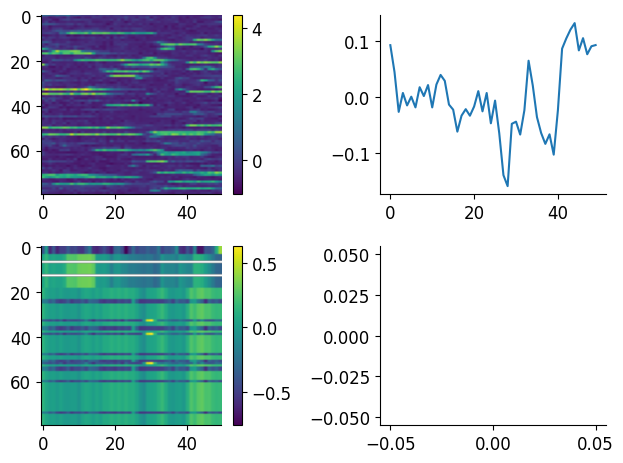

(50, 80)
(array([0, 1, 2], dtype=int32), array([10, 65,  5]))


In [ ]:

cell=8

def rebuild_cell_from_cluster_means(
    cell,
    important_dict,
    ta_activity_dict_for_cluster,
    rng=None
):
    """
    Rebuild a synthetic activity_pattern_cell (pos_bins x n_trials) by:
      1) sampling a cluster label per trial using cluster_expression weights
      2) assigning the corresponding epoch mean trace (early/middle/late)
    """
    if rng is None:
        rng = np.random.default_rng()

    labels = important_dict["TT_list"][cell]["labels_dict"]["clusters_chosen_3"]
    early_cp, late_cp = important_dict["cp_list_NDNF"][cell]
    activity_pattern_cell = important_dict["NDNF_activity_list"][cell]  # (pos_bins, n_trials)

    n_pos, n_trials = activity_pattern_cell.shape

    # cluster labels available for this cell
    clust_dict = ta_activity_dict_for_cluster[cell]
    cluster_ids = np.array(sorted(clust_dict.keys()))

    # weights = fraction of trials in each cluster (should sum to 1)
    w = np.array([clust_dict[c]["cluster_expression"] for c in cluster_ids], dtype=float)
    if w.sum() == 0:
        raise ValueError(f"Cell {cell}: cluster_expression weights sum to 0.")
    w = w / w.sum()

    # sample a cluster label for each trial
    sampled_clusters = rng.choice(cluster_ids, size=n_trials, p=w)

    print(len(sampled_clusters), activity_pattern_cell.shape)

    # decide epoch per trial index
    epoch = np.empty(n_trials, dtype=np.int8)  # 0 early, 1 middle, 2 late
    epoch[:early_cp] = 0
    epoch[early_cp:late_cp] = 1
    epoch[late_cp:] = 2

    # build reconstruction
    recon = np.empty((n_pos, n_trials), dtype=float)
    for t in range(n_trials):
        c = sampled_clusters[t]
        if epoch[t] == 0:
            recon[:, t] = clust_dict[c]["early"]
        elif epoch[t] == 1:
            recon[:, t] = clust_dict[c]["middle"]
        else:
            recon[:, t] = clust_dict[c]["late"]

    return recon, sampled_clusters

recon0, sampled0 = rebuild_cell_from_cluster_means(
    cell=cell,
    important_dict=important_dict,
    ta_activity_dict_for_cluster=ta_activity_dict_for_cluster
)

fig, axs= plt.subplots(2,2)


activity_pattern_cell = important_dict["NDNF_activity_list"][cell]

im = axs[0,0].imshow(activity_pattern_cell.T, aspect='auto')
axs[0,1].plot(np.mean(activity_pattern_cell, axis=1))
fig.colorbar(im, ax=axs[0,0])

im = axs[1,0].imshow(recon0.T, aspect='auto')
fig.colorbar(im, ax=axs[1,0])

axs[1,1].plot(np.mean(recon0, axis=1))

plt.tight_layout()
plt.show()

print(recon0.shape)          # should match original (pos_bins, n_trials)
print(np.unique(sampled0, return_counts=True))



226


(array([114.,   1.,   2.,   4.,   1.,   3.,   6.,   2.,   3.,   1.,   3.,
          4.,   2.,   4.,   2.,   3.,   0.,   2.,   2.,   0.,   1.,   0.,
          2.,   2.,   3.,   1.,   1.,   1.,   2.,   2.,   1.,   3.,   2.,
          4.,   1.,   0.,   4.,   3.,   1.,   4.,   7.,   3.,   3.,   1.,
          2.,   0.,   4.,   2.,   3.,   4.]),
 array([ 0.  ,  0.98,  1.96,  2.94,  3.92,  4.9 ,  5.88,  6.86,  7.84,
         8.82,  9.8 , 10.78, 11.76, 12.74, 13.72, 14.7 , 15.68, 16.66,
        17.64, 18.62, 19.6 , 20.58, 21.56, 22.54, 23.52, 24.5 , 25.48,
        26.46, 27.44, 28.42, 29.4 , 30.38, 31.36, 32.34, 33.32, 34.3 ,
        35.28, 36.26, 37.24, 38.22, 39.2 , 40.18, 41.16, 42.14, 43.12,
        44.1 , 45.08, 46.06, 47.04, 48.02, 49.  ]),
 <BarContainer object of 50 artists>)

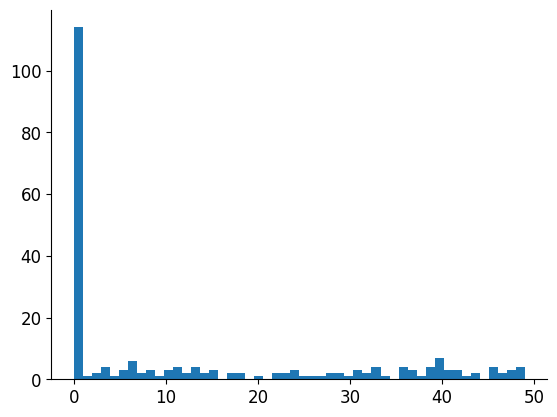

In [ ]:
funky_list2 = [0, 37, 46, 3, 28, 7, 0, 0, 8, 18, 41, 6, 0, 0, 0, 31, 0, 36, 0, 22, 0, 0, 0, 0, 0, 11, 0, 0, 46, 0, 0, 0, 0, 33, 0, 0, 37, 0, 0, 2, 0, 34, 0, 11, 0, 31, 0, 8, 0, 0, 14, 10, 0, 0, 40, 0, 25, 0, 48, 5, 0, 0, 29, 0, 22, 40, 0, 0, 36, 0, 0, 0, 0, 48, 33, 17, 0, 0, 14, 49, 44, 0, 10, 1, 0, 39, 0, 0, 0, 0, 47, 0, 36, 39, 31, 0, 40, 0, 0, 0, 40, 18, 37, 33, 0, 0, 3, 2, 0, 0, 30, 0, 49, 0, 0, 46, 0, 13, 6, 0, 32, 24, 27, 28, 6, 5, 40, 39, 32, 4, 47, 6, 0, 0, 0, 3, 0, 0, 0, 0, 0, 10, 5, 6, 0, 0, 13, 48, 42, 0, 0, 20, 0, 0, 40, 24, 0, 0, 26, 11, 0, 40, 8, 0, 7, 0, 0, 0, 15, 38, 24, 0, 0, 9, 13, 23, 33, 0, 49, 0, 42, 36, 0, 49, 0, 0, 6, 12, 0, 0, 0, 0, 41, 0, 46, 0, 0, 42, 0, 0, 43, 0, 0, 3, 0, 39, 11, 0, 0, 0, 0, 29, 0, 41, 13, 0, 0, 17, 12, 15, 15, 0, 23, 44, 0, 0]

print(len(funky_list2))
plt.hist(funky_list2, bins=50)

vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatten() (2950,)
vel.flatten() (2950,), data.flatte

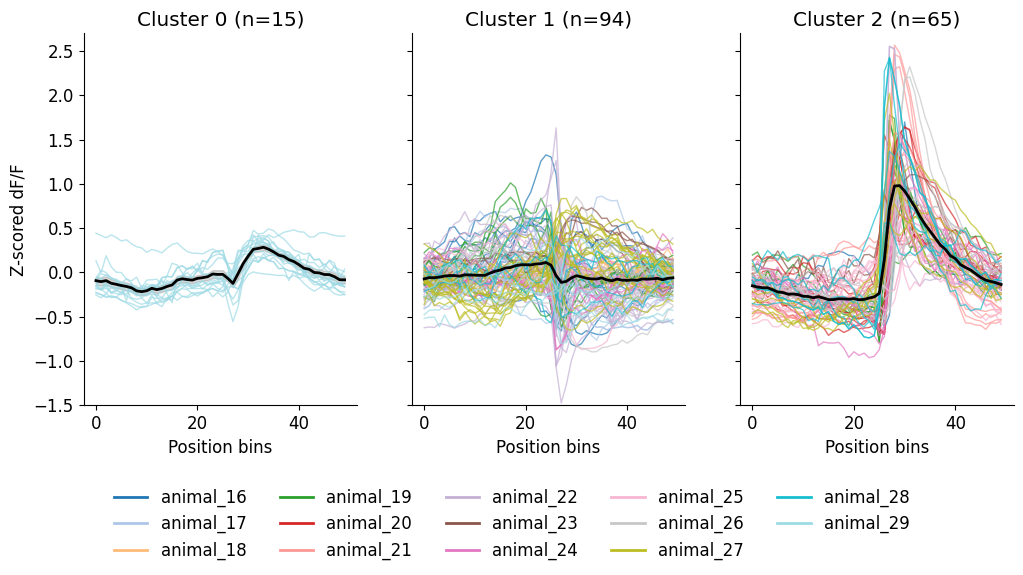

In [ ]:

def get_r_list(fixed_activity_dict_NDNF_newest, factors_dict_NDNF_newest, min_val_EC, data_to_corr=None):

    r_list_vel = []
    vel_per_animal = []
    for animal in fixed_activity_dict_NDNF_newest:
        for cell in fixed_activity_dict_NDNF_newest[animal]:
            vel = factors_dict_NDNF_newest[animal][data_to_corr][:,:min_val_EC]
            vel_per_animal.append(vel)
            data = fixed_activity_dict_NDNF_newest[animal][cell][:,:min_val_EC]

            print(f"vel.flatten() {vel.flatten().shape}, data.flatten() {data.flatten().shape}")
            r, _ = pearsonr(vel.flatten(), data.flatten())
            r_list_vel.append(r)

    array_data = np.array(vel_per_animal)
    r_dict_vel = {"r_list":r_list_vel,
                  "array_data":array_data}

    return r_dict_vel


data_truncated_array_EC, min_val_EC, _ = get_truncated_to_min_data_array(residual_activity_dict_EC)

r_dict_vel = get_r_list(residual_activity_dict_EC, animal_vel_dict, min_val_EC, data_to_corr="Velocity")
# r_dict_licks = get_r_list(residual_activity_dict_EC, animal_lick_dict, min_val_EC, data_to_corr="Licks")
         


save_path = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/all_cells_truncated_fixed_model.pkl'
with open(save_path, 'rb') as f:
    model_20_ndnf_fixed = pickle.load(f)

labels_cells_dict_all_K_ndnf_fixed = get_labels_all_different_Ks_single(model_20_ndnf_fixed, which_vectors=1)

means_dict_cluster_ndnf = plot_reconstructions(labels_cells_dict_all_K_ndnf_fixed, clean_resid_activity_dict_NDNF_newest, r_dict_vel, r_dict_vel, prefix="NDNF 0x0 Raw")

cells_per_animal_dict = get_cells_per_animal_dict(residual_activity_dict_EC)

plot_cluster_traces_by_animal(means_dict_cluster_ndnf,
                              clean_resid_activity_dict_NDNF_newest,
                              K=3,
                              ncol=5, spacing=0.28,
                              title_prefix="", ylim=(-1.5, 2.7))

Loss: 0.4034574383094884 : 100%|██████████| 4000/4000 [01:46<00:00, 37.42it/s] 


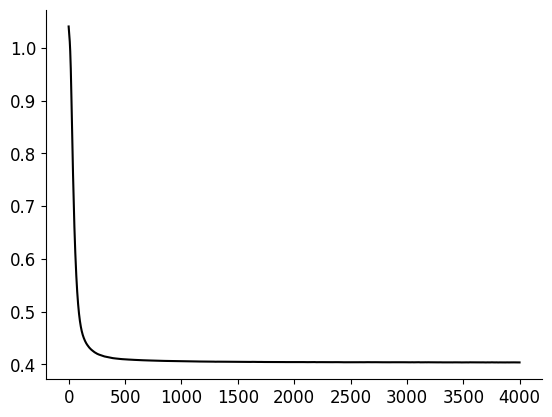

Loss: 0.35105656350159453 : 100%|██████████| 4000/4000 [01:42<00:00, 38.94it/s]


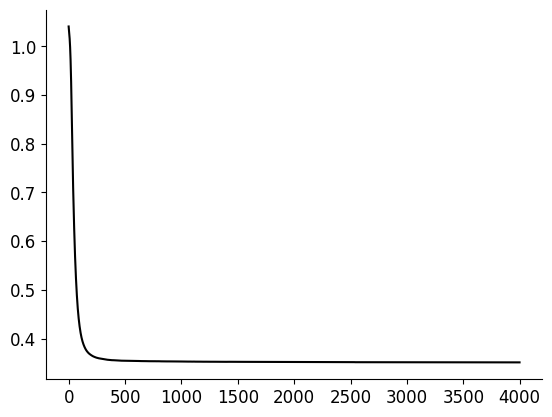

Loss: 0.043522347465508024 : 100%|██████████| 4000/4000 [01:54<00:00, 34.98it/s]


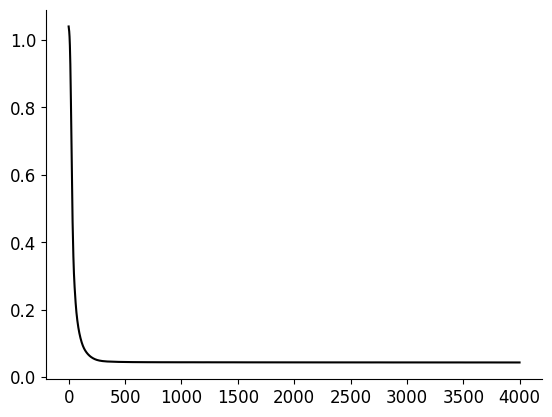

Loss: 0.35266420442558094 : 100%|██████████| 4000/4000 [01:51<00:00, 35.89it/s]


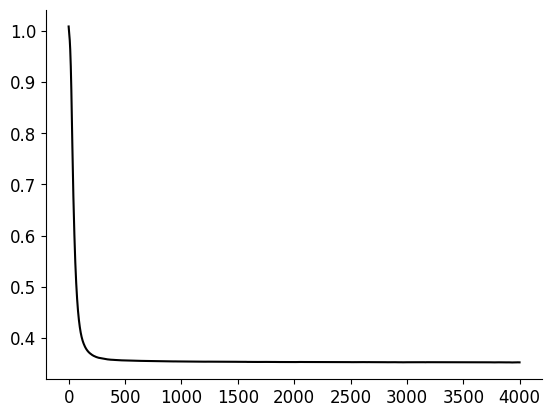

Loss: 0.4046510215109738 : 100%|██████████| 4000/4000 [02:21<00:00, 28.26it/s] 


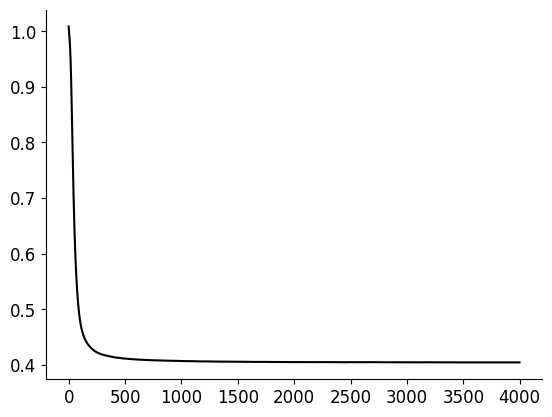

Loss: 0.04826753760308431 : 100%|██████████| 4000/4000 [02:29<00:00, 26.77it/s] 


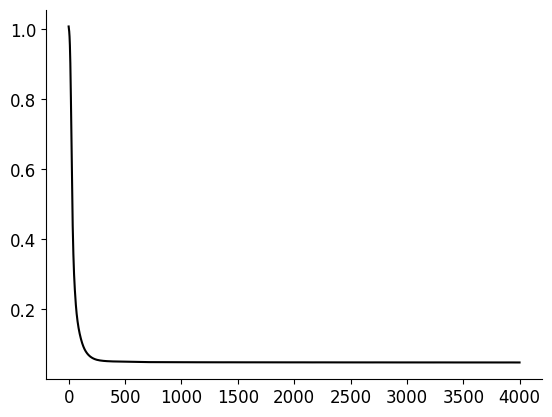

In [ ]:
# model_20_SST_raw_x00 = get_the_tca_model(activity_dict_SST, components=(20,0,0))
# model_20_SST_raw_0x0 = get_the_tca_model(activity_dict_SST, components=(0,20,0))
# model_20_SST_raw_00x = get_the_tca_model(activity_dict_SST, components=(0,0,20))

# model_20_SST_resid_0x0 = get_the_tca_model(residual_activity_dict_SST, components=(0,20,0))
# model_20_SST_resid_x00 = get_the_tca_model(residual_activity_dict_SST, components=(20,0,0))
# model_20_SST_resid_00x = get_the_tca_model(residual_activity_dict_SST, components=(0,0,20))

In [ ]:
# important_dict = {"model_20_SST_resid_0x0":model_20_SST_resid_0x0,
#                   "model_20_SST_resid_x00":model_20_SST_resid_x00,
#                   "model_20_SST_resid_00x":model_20_SST_resid_00x,
#                   "model_20_SST_raw_x00":model_20_SST_raw_x00,
#                   "model_20_SST_raw_0x0":model_20_SST_raw_0x0,
#                   "model_20_SST_raw_00x":model_20_SST_raw_00x
    
# }

# save_path="/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/pickle_every_slice_type_SST.pkl"
# with open(save_path, 'wb') as f:
#     pickle.dump(important_dict, f)

In [ ]:
save_path="/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/pickle_every_slice_type_SST.pkl"
with open(save_path, 'rb') as f:
    important_dict = pickle.load(f)

In [ ]:
model_20_SST_resid_x00 = important_dict["model_20_SST_resid_x00"]
model_20_SST_resid_0x0 = important_dict["model_20_SST_resid_0x0"]
model_20_SST_resid_00x = important_dict["model_20_SST_resid_00x"]

model_20_SST_raw_x00 = important_dict["model_20_SST_raw_x00"]
model_20_SST_raw_0x0 = important_dict["model_20_SST_raw_0x0"]
model_20_SST_raw_00x = important_dict["model_20_SST_raw_00x"]

KeyError: 'model_20_SST_resid_x00'

In [ ]:
labels_cells_dict_all_K_SST_x00_raw = get_labels_all_different_Ks_single(model_20_SST_raw_x00, which_vectors=0)
labels_cells_dict_all_K_SST_0x0_raw = get_labels_all_different_Ks_single(model_20_SST_raw_0x0, which_vectors=1)
labels_cells_dict_all_K_SST_00x_raw = get_labels_all_different_Ks_single(model_20_SST_raw_00x, which_vectors=2)

labels_cells_dict_all_K_SST_x00_resid = get_labels_all_different_Ks_single(model_20_SST_resid_x00, which_vectors=0)
labels_cells_dict_all_K_SST_0x0_resid = get_labels_all_different_Ks_single(model_20_SST_resid_0x0, which_vectors=1)
labels_cells_dict_all_K_SST_00x_resid = get_labels_all_different_Ks_single(model_20_SST_resid_00x, which_vectors=2)

F.shape (20, 75, 50)  W.shape (20, 63)
X shape (latent×pos flat): (75, 1000)


/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


F.shape (20, 63, 50)  W.shape (20, 75)
X shape (mean over pos): (75, 20)
F.shape (20, 63, 75)  W.shape (20, 50)
(75, 1260)
F.shape (20, 75, 50)  W.shape (20, 63)
X shape (latent×pos flat): (75, 1000)
F.shape (20, 63, 50)  W.shape (20, 75)
X shape (mean over pos): (75, 20)
F.shape (20, 63, 75)  W.shape (20, 50)
(75, 1260)


In [ ]:
means_dict_cluster_00x_raw = plot_reconstructions(labels_cells_dict_all_K_SST_00x_raw, activity_dict_SST, r_dict_vel, r_dict_licks, prefix="SST 00x Raw")
means_dict_cluster_0x0_raw = plot_reconstructions(labels_cells_dict_all_K_SST_0x0_raw, activity_dict_SST, r_dict_vel, r_dict_licks, prefix="SST 0x0 Raw")
means_dict_cluster_x00_raw = plot_reconstructions(labels_cells_dict_all_K_SST_x00_raw, activity_dict_SST, r_dict_vel, r_dict_licks, prefix="SST x00 Raw")

############ different r list? 

means_dict_cluster_x00_resid = plot_reconstructions(labels_cells_dict_all_K_SST_x00_resid, residual_activity_dict_SST, r_dict_vel, r_dict_licks, prefix="SST x00 Residuals")
means_dict_cluster_0x0_resid = plot_reconstructions(labels_cells_dict_all_K_SST_0x0_resid, residual_activity_dict_SST, r_dict_vel, r_dict_licks, prefix="SST 0x0 Residuals")
means_dict_cluster_00x_resid = plot_reconstructions(labels_cells_dict_all_K_SST_00x_resid, residual_activity_dict_SST, r_dict_vel, r_dict_licks, prefix="SST 00x Residuals")


NameError: name 'labels_cells_dict_all_K_SST_00x_raw' is not defined

In [ ]:
count=0
for animal in activity_dict_SST:
    for cell in activity_dict_SST[animal]:
        count+=1
print(count)

75


F.shape (20, 63, 50)  W.shape (20, 75)
X shape (mean over pos): (75, 20)


IndexError: boolean index did not match indexed array along dimension 0; dimension is 20 but corresponding boolean dimension is 75

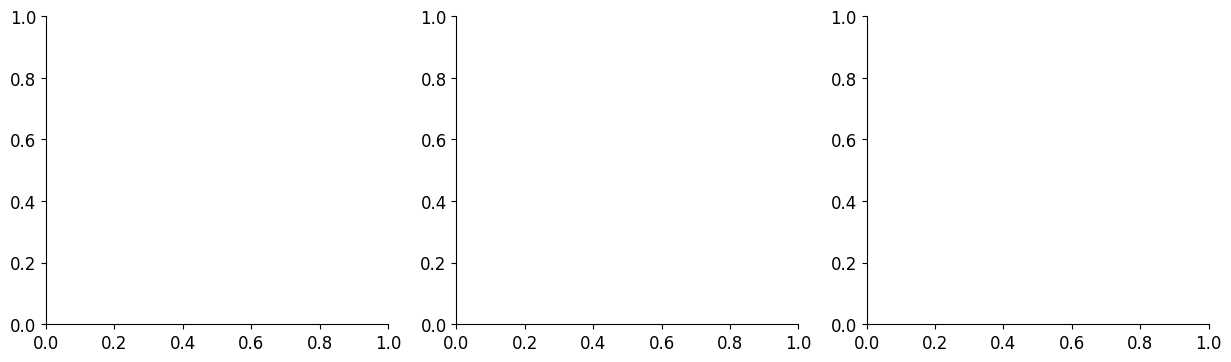

In [ ]:
out = pca_cluster_viz(
    model_20_SST_raw_0x0,
    which_vectors=1,
    feature_space="loadings",     # or whatever you’re using in get_cell_features
    feature_mode="0x0",     # your existing arg
    n_cells_expected=75,         # fill with your expected count
    n_latents_expected=20,       # fill with your expected count
    n_components=3,
    num_clusters=2,               # <= set 2 if you want the LDA+orth trick; ≥3 uses LDA(2)
    title_prefix="SST 3D PCA")


In [ ]:
cells_per_animal_dict = get_cells_per_animal_dict(activity_dict_SST)

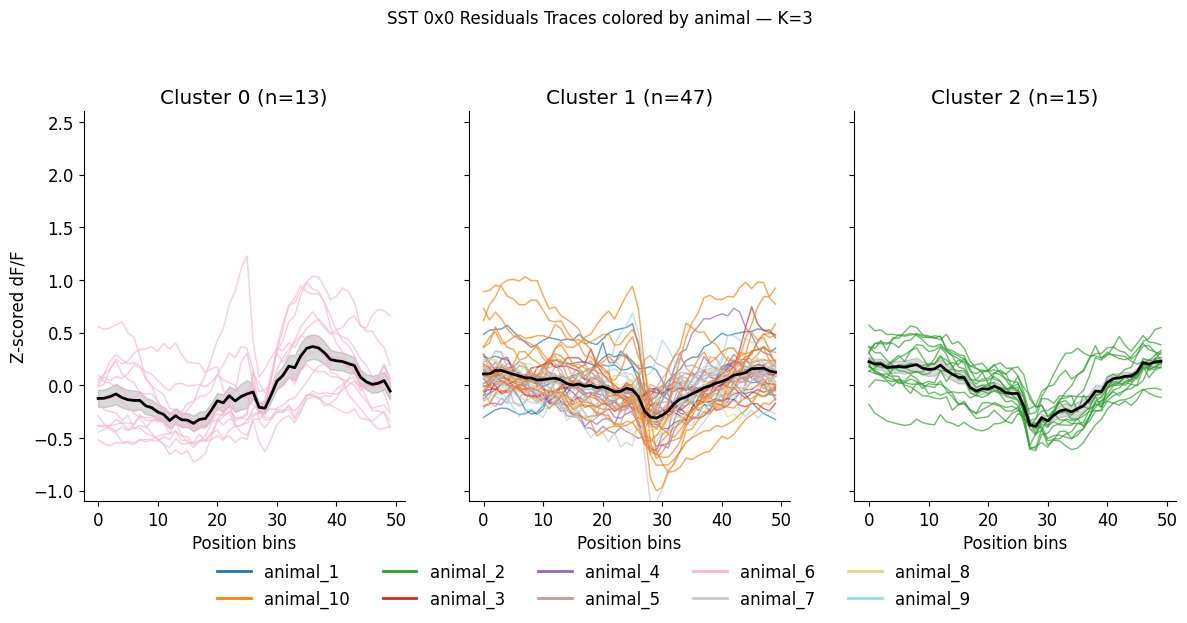

In [ ]:
# plot_cluster_traces_by_animal(means_dict_cluster_0x0_raw,
#                               activity_dict_SST,
#                               cells_per_animal_dict,
#                               K=3,spacing=0.2,ncol=5,
#                               title_prefix="SST 0x0 Raw")

plot_cluster_traces_by_animal(means_dict_cluster_0x0_resid,
                              residual_activity_dict_SST,
                              cells_per_animal_dict,
                              K=3,
                              ncol=5, spacing=0.2,
                              title_prefix="SST 0x0 Residuals")

In [ ]:
import os
p = "/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/spike_sim.pkl"
print(os.path.getsize(p), "bytes")
print(round(os.path.getsize(p)/1024**2, 2), "MB")

766218043 bytes
730.72 MB


In [ ]:
p = "/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/spike_sim.pkl"

with open(p, 'rb') as f:
    intermediates = pickle.load(f)
print(intermediates.keys())

AttributeError: Can't get attribute 'SimConfig' on <module '__main__'>

In [ ]:
pca_cluster_viz(model_20_SST_raw_0x0, which_vectors=1, feature_space="loadings", feature_mode="0x0", n_cells_expected=73, n_latents_expected=20, n_components=3, num_clusters=2, title_prefix="NDNF 3D PCA")




NameError: name 'pca_cluster_viz' is not defined

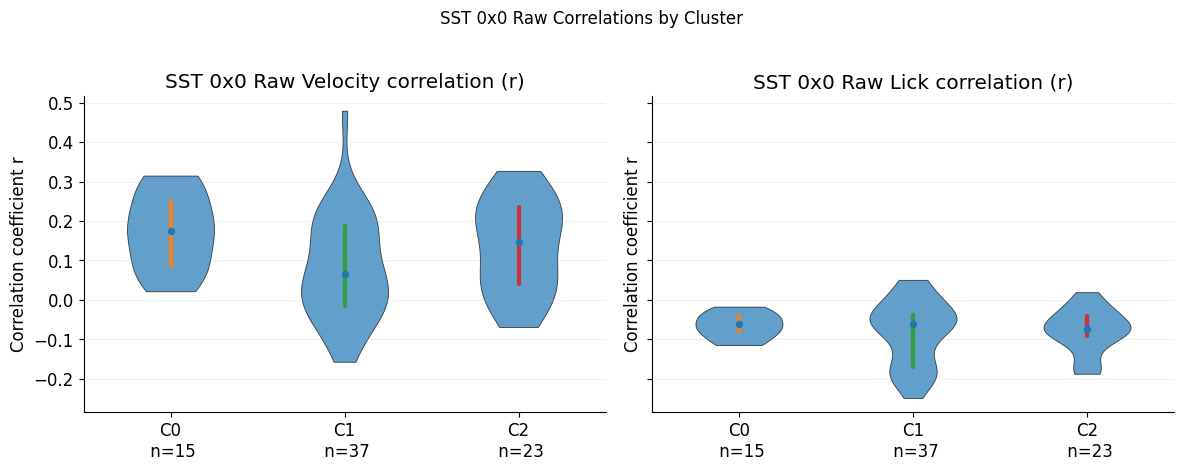

In [ ]:
plot_violin_correlations_side_by_side(means_dict_cluster_0x0_raw, num_clusters=3, title="SST 0x0 Raw")


In [37]:

mse_dir = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/cell_SST_model_ranks20_contig_x00_cells"
cell_SST_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)

mse_dir = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/cell_EC_model_ranks20_contig_x00_cells"
cell_EC_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)

mse_dir = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/real_final_NDNF_model_ranks20_contig_x00_cell"
cell_NDNF_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)

# def get_cp_dict(cell_SST_model_ranks20_contig_x00):
#     changepoints_dict = {}
#     for animal in cell_SST_model_ranks20_contig_x00[20]:
#         changepoints_cell_dict = {}
#         for cell in cell_SST_model_ranks20_contig_x00[20][animal]:
#             labels = cell_SST_model_ranks20_contig_x00[20][animal][cell][1][f'cell_{cell}']["labels_dict"]["clusters_chosen_3"]
#             changepoints = np.where(np.diff(labels) != 0)[0]
#             changepoints_cell_dict[cell] = changepoints
#         changepoints_dict[animal] = changepoints_cell_dict

#     return changepoints_dict

# def get_fixed_model_dict_NDNF_newest(cell_NDNF_model_ranks20_contig_x00):
#     fixed_model_dict_NDNF_newest = {20:{}}
#     for animal in cell_NDNF_model_ranks20_contig_x00[20]:
#         if 17 < animal < 31:
#             fixed_model_dict_NDNF_newest[20][animal-18] = cell_NDNF_model_ranks20_contig_x00[20][animal]
#     return fixed_model_dict_NDNF_newest

fixed_model_dict_NDNF_newest = get_fixed_model_dict_NDNF_newest(cell_NDNF_model_ranks20_contig_x00)

cp_dict_EC = get_cp_dict(cell_EC_model_ranks20_contig_x00)
cp_dict_NDNF = get_cp_dict(fixed_model_dict_NDNF_newest)
cp_dict_SST = get_cp_dict(cell_SST_model_ranks20_contig_x00)

Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 5 cells
    Animal 1: 15 cells
    Animal 2: 6 cells
    Animal 3: 4 cells
    Animal 4: 13 cells
    Animal 5: 13 cells
    Animal 6: 3 cells
    Animal 7: 3 cells
    Animal 8: 3 cells
    Animal 9: 10 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 192 cells
    Animal 1: 150 cells
    Animal 2: 154 cells
    Animal 3: 82 cells
    Animal 4: 74 cells
    Animal 5: 64 cells
    Animal 6: 76 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 12 cells
    Animal 1: 16 cells
    Animal 2: 4 cells
    Animal 3: 10 cells
    Animal 4: 8 cells
    Animal 5: 7 cells
    Animal 6: 11 cells
    Animal 7: 10 cells
    Animal 8: 17 cells
    Animal 9: 17 cells
    Animal 10: 9 cells
    Animal 11: 6 cells
    Animal 12: 10 cells
    Animal 13: 9 cells
    Animal 14: 6 cells
    Animal 15: 12 cells
    Animal 16: 7 cells
    Animal 17: 7 cells
    Animal 18: 7 cells
    Animal 19: 10 cells
    Animal 20: 9 cells
    Animal 21: 

NameError: name 'get_fixed_model_dict_NDNF_newest' is not defined

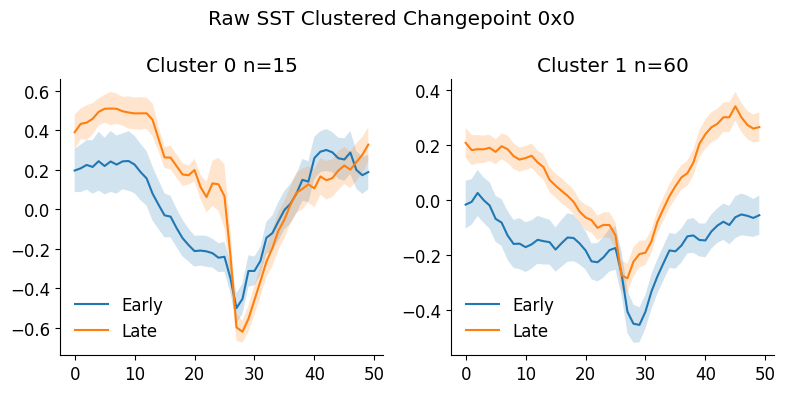

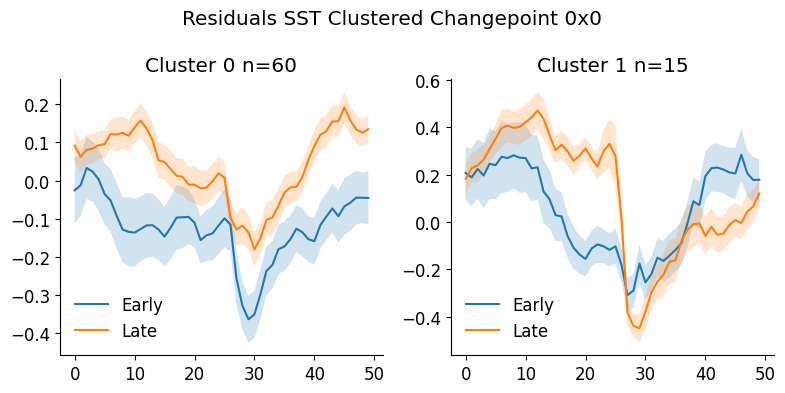

In [ ]:
activity_early_array, activity_array_late = get_activity_cut_learn(activity_dict_SST, cp_dict_SST)
plot_clustered_data_learn(means_dict_cluster_0x0_raw, activity_early_array, activity_array_late, K=2, title="Raw SST Clustered Changepoint 0x0")

activity_early_array_resid, activity_array_late_resid = get_activity_cut_learn(residual_activity_dict_SST, cp_dict_SST)
plot_clustered_data_learn(means_dict_cluster_0x0_resid, activity_early_array_resid, activity_array_late_resid, K=2, title="Residuals SST Clustered Changepoint 0x0")



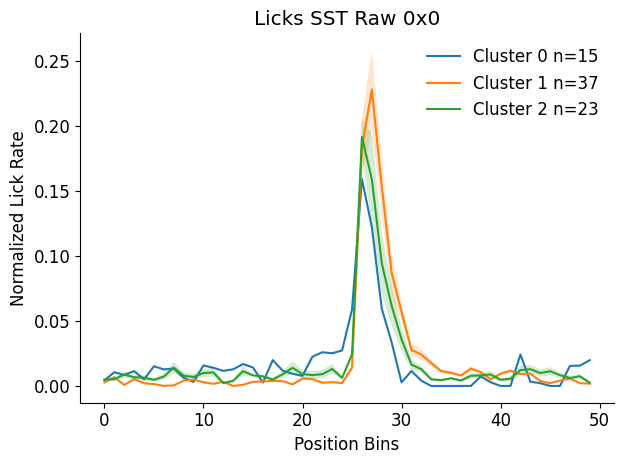

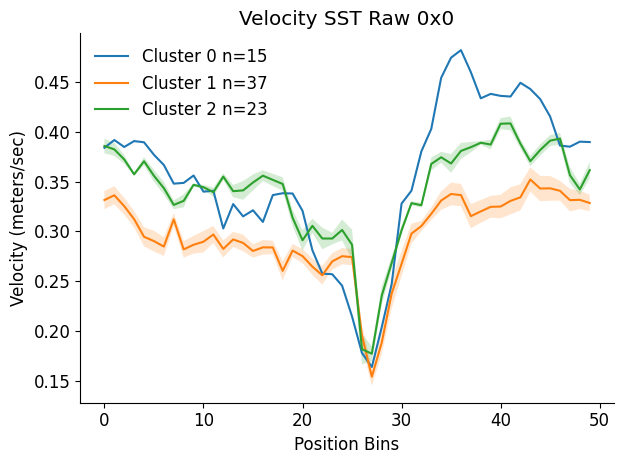

In [ ]:
def plot_lick_vel_data_clust(means_dict_cluster_0x0_raw, num_clusters=3, use_vel=False, title=None):

    if use_vel:
        vel_data = means_dict_cluster_0x0_raw[num_clusters]["vel_data_sliced_dict"]
    else:
        vel_data = means_dict_cluster_0x0_raw[num_clusters]["lick_data_sliced_dict"]


    # fig, axs = plt.subplots(1,len(vel_data), figsize=(len(vel_data)*4, 4))
    for clust in vel_data:
        vel_array = vel_data[clust]
        trial_av_vel_array = np.mean(vel_array, axis=2)

        mean_over_cells = np.mean(trial_av_vel_array, axis=0)
        sem_over_cells = sem(trial_av_vel_array, axis=0)

        plt.plot(mean_over_cells, label=f"Cluster {clust} n={vel_array.shape[0]}")
        plt.fill_between(range(len(mean_over_cells)), mean_over_cells-sem_over_cells, mean_over_cells+sem_over_cells, alpha=0.2)
        # plt.title(f"Cluster {clust}")
        plt.xlabel("Position Bins")
        if use_vel:
            plt.ylabel(f"Velocity (meters/sec)")
        else:
            plt.ylabel(f"Normalized Lick Rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_lick_vel_data_clust(means_dict_cluster_0x0_raw, num_clusters=3, use_vel=False, title="Licks SST Raw 0x0")
plot_lick_vel_data_clust(means_dict_cluster_0x0_raw, num_clusters=3, use_vel=True, title="Velocity SST Raw 0x0")